Needed results and tables

- layerwise AP and AUC
- plot with layerwise jepa-scores real vs fake on ForenSynths val
- AUC and AP for deltas between layers

In [2]:
from pathlib import Path
import pandas as pd
from sklearn.metrics import roc_auc_score, average_precision_score, accuracy_score, f1_score
import matplotlib.pyplot as plt
import numpy as np
import statistics as stat
import seaborn as sns

In [3]:
def read_jsonl(df_path):
    with open(df_path, "r") as f:
        next(f)
        df_out = pd.read_json(f, lines=True)
    return df_out

In [4]:
def scores_layers(df, model_name):    
    mask = df.columns.str.contains("layer")
    layers = df.columns[mask]

    auc = []
    ap = []

    for i, layer in enumerate(layers):
        auc.append(roc_auc_score(df["label"], df[layer]))
        ap.append(average_precision_score(df["label"], df[layer]))

    print(f"AUC: {auc}")
    print(f"AP: {ap}")
    x = np.arange(len(layers)) *2
    width = 0.7

    fig, ax = plt.subplots()
    ax.bar(x - width / 2, auc, width, label="AUC")
    ax.bar(x + width / 2, ap,  width, label="AP")

    ax.set_xticks(x, layers, rotation=45, ha="right")
    ax.set_ylim(0, 1.1)
    ax.legend()
    plt.title(f'{model_name} for ForenSynths_val')
    plt.xlabel('Layers')
    plt.ylabel('%')
    plt.show()
    
    return None

In [5]:
def trajectory_plot(df, interval, layer_num):
    """ layer_cols = [f"layer_{i}" for i in range(12)] + ["layer_norm"]
    X_test = df[layer_cols].values
    y_test = df["label"].values """

    if layer_num == 12:
        layer_cols = [f"layer_{i}" for i in range(12)] + ["layer_norm"]
        X_test = df[layer_cols].values
        y_test = df["label"].values
        layer_indices = list(range(12)) + [12]
    elif layer_num == 24:
        layer_cols = [f"layer_{i}" for i in range(24)] + ["layer_norm"]
        X_test = df[layer_cols].values
        y_test = df["label"].values
        layer_indices = list(range(24)) + [24]
    else: print("Layer number not available!")
    real_all  = X_test[y_test == 0]
    fake_all  = X_test[y_test == 1]
    real_mean = real_all.mean(axis=0)
    real_std  = real_all.std(axis=0)
    fake_mean = fake_all.mean(axis=0)
    fake_std  = fake_all.std(axis=0)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, x_range in zip(axes, [layer_indices, list(range(interval[0], interval[1]))]):
        idx = [layer_indices.index(i) for i in x_range]
        ax.plot(x_range, real_mean[idx], color='blue', label=f'real (n={len(real_all)})', linewidth=2)
        ax.fill_between(x_range, real_mean[idx] - real_std[idx], real_mean[idx] + real_std[idx], color='blue', alpha=0.2)
        ax.plot(x_range, fake_mean[idx], color='red',  label=f'fake (n={len(fake_all)})', linewidth=2)
        ax.fill_between(x_range, fake_mean[idx] - fake_std[idx], fake_mean[idx] + fake_std[idx], color='red',  alpha=0.2)
        ax.set_xlabel('Layer')
        ax.set_ylabel('Score')
        ax.legend()

    axes[0].set_title('Mean trajectory ± 1 std')
    axes[1].set_title(f'Layers {interval[0]}–{interval[1]}')
    plt.tight_layout()
    plt.show()

In [6]:
""" generators = ["progan", "stylegan2", "stylegan", "biggan", "stargan", "gaugan", "cyclegan"]
def specific_layer_score(df, generators, layer):
    auc_list = []
    ap_list = []
    for generator in generators:
        df_gen = df[df["img_path"].str.contains(generator + "/")].copy()
        auc = roc_auc_score(df_gen.label, df_gen[layer])
        auc_list.append(auc)
        ap = average_precision_score(df_gen.label, df_gen[layer])
        ap_list.append(ap)
        print(f"{generator} -> AUC:{auc}, AP:{ap}")
    print(f"Macro-average AUC: {stat.mean(auc_list)}")
    print(f"Macro-average AP: {stat.mean(ap_list)}") """

' generators = ["progan", "stylegan2", "stylegan", "biggan", "stargan", "gaugan", "cyclegan"]\ndef specific_layer_score(df, generators, layer):\n    auc_list = []\n    ap_list = []\n    for generator in generators:\n        df_gen = df[df["img_path"].str.contains(generator + "/")].copy()\n        auc = roc_auc_score(df_gen.label, df_gen[layer])\n        auc_list.append(auc)\n        ap = average_precision_score(df_gen.label, df_gen[layer])\n        ap_list.append(ap)\n        print(f"{generator} -> AUC:{auc}, AP:{ap}")\n    print(f"Macro-average AUC: {stat.mean(auc_list)}")\n    print(f"Macro-average AP: {stat.mean(ap_list)}") '

In [1]:
generators = ["stylegan", "stargan", "stylegan2", "biggan", "progan", "gaugan", "cyclegan"]
def analyze_layer(test, cal, generators, layer, plot_type="kde"):
    threshold = cal[layer].mean() + cal[layer].std()
    print(f"Mean+std cal set threshold: {threshold:.4f}\n")

    test = test.copy()
    test["_pred"] = (test[layer] >= threshold).astype(int)

    auc_list, ap_list, acc_list, f1_list = [], [], [], []
    for generator in generators:
        df_gen = test[test["img_path"].str.contains(generator + "/")].copy()
        auc = roc_auc_score(df_gen.label, df_gen[layer])
        ap  = average_precision_score(df_gen.label, df_gen[layer])
        acc = accuracy_score(df_gen.label.astype(int), df_gen["_pred"])
        f1  = f1_score(df_gen.label.astype(int), df_gen["_pred"])
        auc_list.append(auc); ap_list.append(ap)
        acc_list.append(acc); f1_list.append(f1)
        print(f"{generator:12s}  ACC:{acc:.4f}  AP:{ap:.4f}  AUC:{auc:.4f}  F1:{f1:.4f}")

    print(f"\nMacro-average AUC: {stat.mean(auc_list):.4f}")
    print(f"Macro-average AP:  {stat.mean(ap_list):.4f}")
    print(f"Macro-average ACC: {stat.mean(acc_list):.4f}")
    print(f"Macro-average F1:  {stat.mean(f1_list):.4f}")

    # --- Per-generator distribution plots ---
    cal_plot = cal[[layer]].copy()
    cal_plot["class"] = "cal"

    ncols = min(len(generators), 4)
    nrows = int(np.ceil(len(generators) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    axes = np.array(axes).flatten()

    for i, generator in enumerate(generators):
        ax = axes[i]

        df_real = test[
            test["img_path"].str.contains(generator + "/") & (test["label"] == 0)
        ][[layer]].copy()
        df_real["class"] = "real"

        df_fake = test[
            test["img_path"].str.contains(generator + "/") & (test["label"] == 1)
        ][[layer]].copy()
        df_fake["class"] = "fake"

        plot_df = pd.concat([cal_plot, df_real, df_fake])

        if plot_type == "kde":
            sns.kdeplot(data=plot_df, x=layer, hue="class",
                        hue_order=["cal", "real", "fake"],
                        common_norm=False, ax=ax, fill=True, alpha=0.2)
        else:
            sns.histplot(data=plot_df, x=layer, hue="class",
                         hue_order=["cal", "real", "fake"],
                         stat="density", common_norm=False, element="step", ax=ax)

        vline = ax.axvline(threshold, color="black", linestyle="--", linewidth=1.2)
        ax.set_title(generator)
        ax.set_xlabel("Score")

        leg = ax.get_legend()
        handles = leg.legend_handles + [vline]
        labels = [t.get_text() for t in leg.get_texts()] + [f"thr={threshold:.3f}"]
        ax.legend(handles=handles, labels=labels, fontsize=8)

    for j in range(len(generators), len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(f"Score distributions by generator — layer: {layer}")
    fig.tight_layout()
    plt.show()


In [157]:
""" def specific_layer_score_new_gen(df, layer, plot_type="kde"):
    new_gen = ["dalle3", "firefly", "flux", "midjourney-v5", "sd3", "sdxl"]
    df_gen_real = df[df["img_path"].str.contains("real/")].copy()
    df_gen_real["class"] = "real"

    auc_list = []
    ap_list = []
    plot_frames = [df_gen_real]

    for generator in new_gen:
        df_gen_fake = df[df["img_path"].str.contains(generator + "/")].copy()
        df_gen_fake["class"] = generator

        concat = pd.concat([df_gen_fake, df_gen_real])
        auc = roc_auc_score(concat.label, concat[layer])
        ap = average_precision_score(concat.label, concat[layer])
        auc_list.append(auc)
        ap_list.append(ap)
        print(f"{generator} -> AUC:{auc}, AP:{ap}")

        plot_frames.append(df_gen_fake)

    print(f"Macro-average AUC: {stat.mean(auc_list)}")
    print(f"Macro-average AP: {stat.mean(ap_list)}")

    # --- Distribution plot ---
    plot_df = pd.concat(plot_frames)

    fig, ax = plt.subplots(figsize=(8, 5))
    if plot_type == "kde":
        sns.kdeplot(data=plot_df, x=layer, hue="class", common_norm=False, ax=ax, fill=True, alpha=0.2)
    else:
        sns.histplot(data=plot_df, x=layer, hue="class", stat="density", common_norm=False,
                     element="step", ax=ax)

    ax.set_title(f"Score distribution by class — layer: {layer}")
    ax.set_xlabel("Score")
    fig.tight_layout()
    plt.show()

    return auc_list, ap_list """

def specific_layer_score_new_gen(df, layer, cal=None, plot_type="kde"):
    new_gen = ["sd3", "flux", "sdxl", "dalle3", "firefly", "midjourney-v5"]
    df_gen_real = df[df["img_path"].str.contains("real/")].copy()
    df_gen_real["class"] = "real"

    threshold = None
    if cal is not None:
        threshold = cal[layer].mean() + cal[layer].std()
        print(f"Mean+std cal set threshold: {threshold:.4f}\n")

    auc_list, ap_list, acc_list, f1_list = [], [], [], []

    for generator in new_gen:
        df_gen_fake = df[df["img_path"].str.contains(generator + "/")].copy()
        concat = pd.concat([df_gen_fake, df_gen_real])
        auc = roc_auc_score(concat.label, concat[layer])
        ap = average_precision_score(concat.label, concat[layer])
        auc_list.append(auc)
        ap_list.append(ap)

        if threshold is not None:
            concat = concat.copy()
            concat["_pred"] = (concat[layer] >= threshold).astype(int)
            acc = accuracy_score(concat.label.astype(int), concat["_pred"])
            f1  = f1_score(concat.label, concat["_pred"])
            acc_list.append(acc); f1_list.append(f1)
            print(f"{generator:20s}  ACC:{acc:.4f}  AP:{ap:.4f}  AUC:{auc:.4f}  F1:{f1:.4f}")
        else:
            print(f"{generator} -> AUC:{auc:.4f}, AP:{ap:.4f}")

    print(f"Macro-average AUC: {stat.mean(auc_list):.4f}")
    print(f"Macro-average AP:  {stat.mean(ap_list):.4f}")
    if acc_list:
        print(f"Macro-average ACC: {stat.mean(acc_list):.4f}")
        print(f"Macro-average F1:  {stat.mean(f1_list):.4f}")

    # --- Per-generator distribution plots ---
    cal_plot = cal[[layer]].copy() if cal is not None else None
    if cal_plot is not None:
        cal_plot["class"] = "cal"

    hue_order = (["cal", "real", "fake"] if cal is not None else ["real", "fake"])

    ncols = 3
    nrows = int(np.ceil(len(new_gen) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    axes = np.array(axes).flatten()

    for i, generator in enumerate(new_gen):
        ax = axes[i]

        df_fake = df[df["img_path"].str.contains(generator + "/")][[layer]].copy()
        df_fake["class"] = "fake"

        frames = ([cal_plot] if cal_plot is not None else []) + [df_gen_real[[layer, "class"]], df_fake]
        plot_df = pd.concat(frames)

        if plot_type == "kde":
            sns.kdeplot(data=plot_df, x=layer, hue="class", hue_order=hue_order,
                        common_norm=False, ax=ax, fill=True, alpha=0.2)
        else:
            sns.histplot(data=plot_df, x=layer, hue="class", hue_order=hue_order,
                         stat="density", common_norm=False, element="step", ax=ax)

        if threshold is not None:
            vline = ax.axvline(threshold, color="black", linestyle="--", linewidth=1.2)
            leg = ax.get_legend()
            handles = leg.legend_handles + [vline]
            labels = [t.get_text() for t in leg.get_texts()] + [f"thr={threshold:.3f}"]
            ax.legend(handles=handles, labels=labels, fontsize=8)

        ax.set_title(generator)
        ax.set_xlabel("Score")

    for j in range(len(new_gen), len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(f"Score distributions by generator — layer: {layer}")
    fig.tight_layout()
    plt.show()

In [158]:
def delta_mining(df):
    results = []
    for i in range(np.count_nonzero(df.columns.str.contains("layer") == True) -1): # layer_norm is just a linear transformation
        for j in range(i):
            #df[f"layer_{i}-{j}"] = df[f"layer_{i}"] - df[f"layer_{j}"]
            ap = average_precision_score(df.label, df[f"layer_{i}"] - df[f"layer_{j}"])
            auc = roc_auc_score(df.label, df[f"layer_{i}"] - df[f"layer_{j}"])
            results.append({"delta": f"layer_{i}-{j}", "auc": auc, "ap": ap})
    
    return pd.DataFrame(results).sort_values(by="auc", ascending=False)
    

## Clip ViT-B/16

In [159]:
clip_b16_ForenSynths_val_df = read_jsonl("/home/tischuet/zero-shot-deepfake-detection/outputs/vit_base_patch16_clip_224_openai/vit_base_patch16_clip_224_openai_layerwise_ForenSynths_val.jsonl")
clip_b16_Imagenet5k_df = read_jsonl("/home/tischuet/zero-shot-deepfake-detection/outputs/vit_base_patch16_clip_224_openai/vit_base_patch16_clip_224_openai_layerwise_Imagenet_val_5k.jsonl")

clip_b16_ForenSynths_test_df = read_jsonl("/home/tischuet/zero-shot-deepfake-detection/outputs/vit_base_patch16_clip_224_openai/vit_base_patch16_clip_224_openai_layerwise_ForenSynths.jsonl")
clip_16_NewGenerators_test_df = read_jsonl("/home/tischuet/zero-shot-deepfake-detection/outputs/vit_base_patch16_clip_224_openai/vit_base_patch16_clip_224_openai_layerwise_New-Generator.jsonl")

AUC: [0.5090525, 0.51038653125, 0.5111451875, 0.524567625, 0.52600496875, 0.5609826874999999, 0.5954856562499999, 0.5544575, 0.67935896875, 0.77564065625, 0.80233328125, 0.8524054062499999, 0.86254225]
AP: [0.5040849232066309, 0.503989442223621, 0.5032203732354656, 0.5232478245449338, 0.5302332440935194, 0.5644864995475628, 0.6020853316010403, 0.562461179224933, 0.6799960178618181, 0.7848988099909149, 0.8165069397141735, 0.8639821945366377, 0.868942242934444]


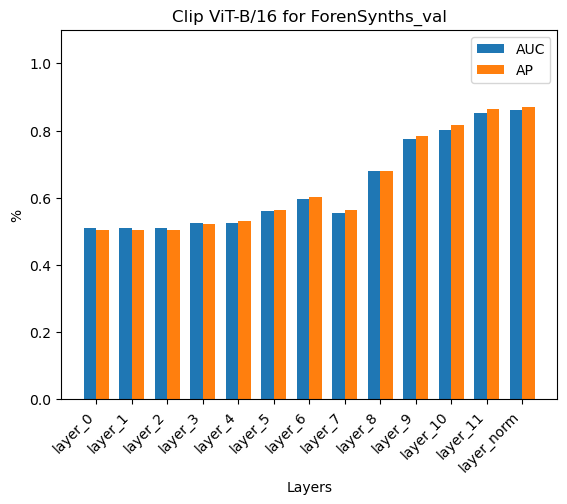

In [160]:
scores_layers(clip_b16_ForenSynths_val_df, "Clip ViT-B/16")

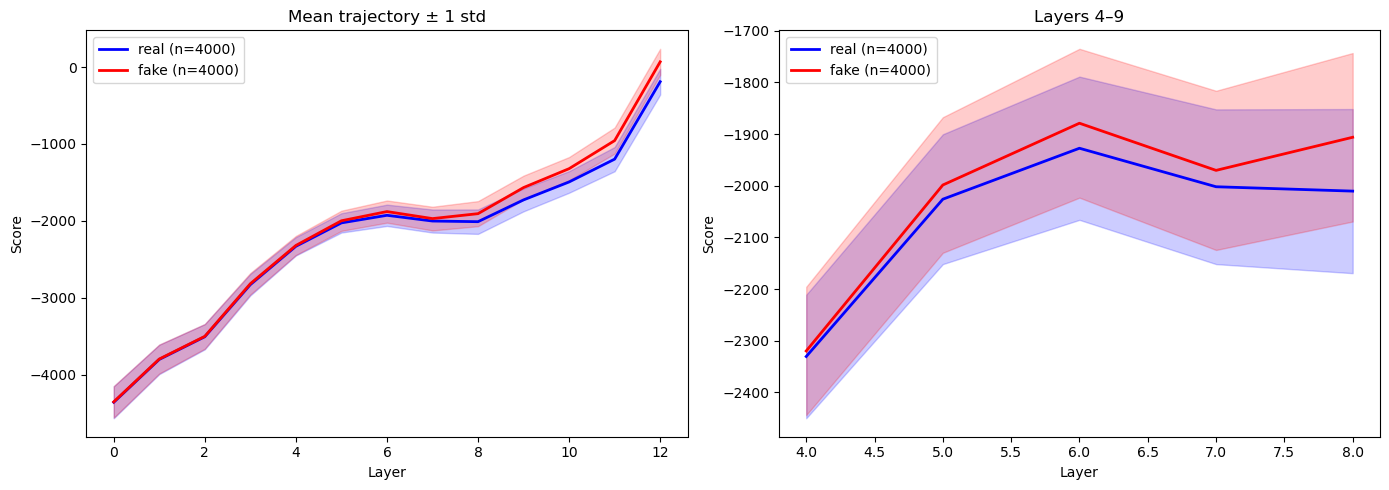

In [161]:
trajectory_plot(clip_b16_ForenSynths_val_df, (4,9), 12)

In [162]:
delta_mining(clip_b16_ForenSynths_val_df)

,delta,auc,ap
43,layer_9-7,0.909209,0.922904
59,layer_11-4,0.891545,0.893381
35,layer_8-7,0.880789,0.881973
58,layer_11-3,0.877531,0.860022
49,layer_10-4,0.869719,0.876325
...,...,...,...
0,layer_1-0,0.496955,0.498134
1,layer_2-0,0.496511,0.498021
2,layer_2-1,0.496436,0.497596
9,layer_4-3,0.485049,0.495957


In [163]:
clip_b16_Imagenet5k_df["layer_9-7"] = clip_b16_Imagenet5k_df["layer_9"] - clip_b16_Imagenet5k_df["layer_7"]
clip_b16_ForenSynths_test_df["layer_9-7"] = clip_b16_ForenSynths_test_df["layer_9"] - clip_b16_ForenSynths_test_df["layer_7"]
clip_16_NewGenerators_test_df["layer_9-7"] = clip_16_NewGenerators_test_df["layer_9"] - clip_16_NewGenerators_test_df["layer_7"]

Mean+std cal set threshold: -9.3868

stylegan      ACC:0.6265  AP:0.7063  AUC:0.7085  F1:0.5249
stargan       ACC:0.6498  AP:0.9507  AUC:0.9562  F1:0.4665
stylegan2     ACC:0.5901  AP:0.6670  AUC:0.6657  F1:0.4265
biggan        ACC:0.5990  AP:0.6541  AUC:0.6273  F1:0.4892
progan        ACC:0.7765  AP:0.8674  AUC:0.8615  F1:0.7548
gaugan        ACC:0.7513  AP:0.8382  AUC:0.8267  F1:0.7273
cyclegan      ACC:0.5746  AP:0.7199  AUC:0.7348  F1:0.3062

Macro-average AUC: 0.7687
Macro-average AP:  0.7719
Macro-average ACC: 0.6525
Macro-average F1:  0.5279


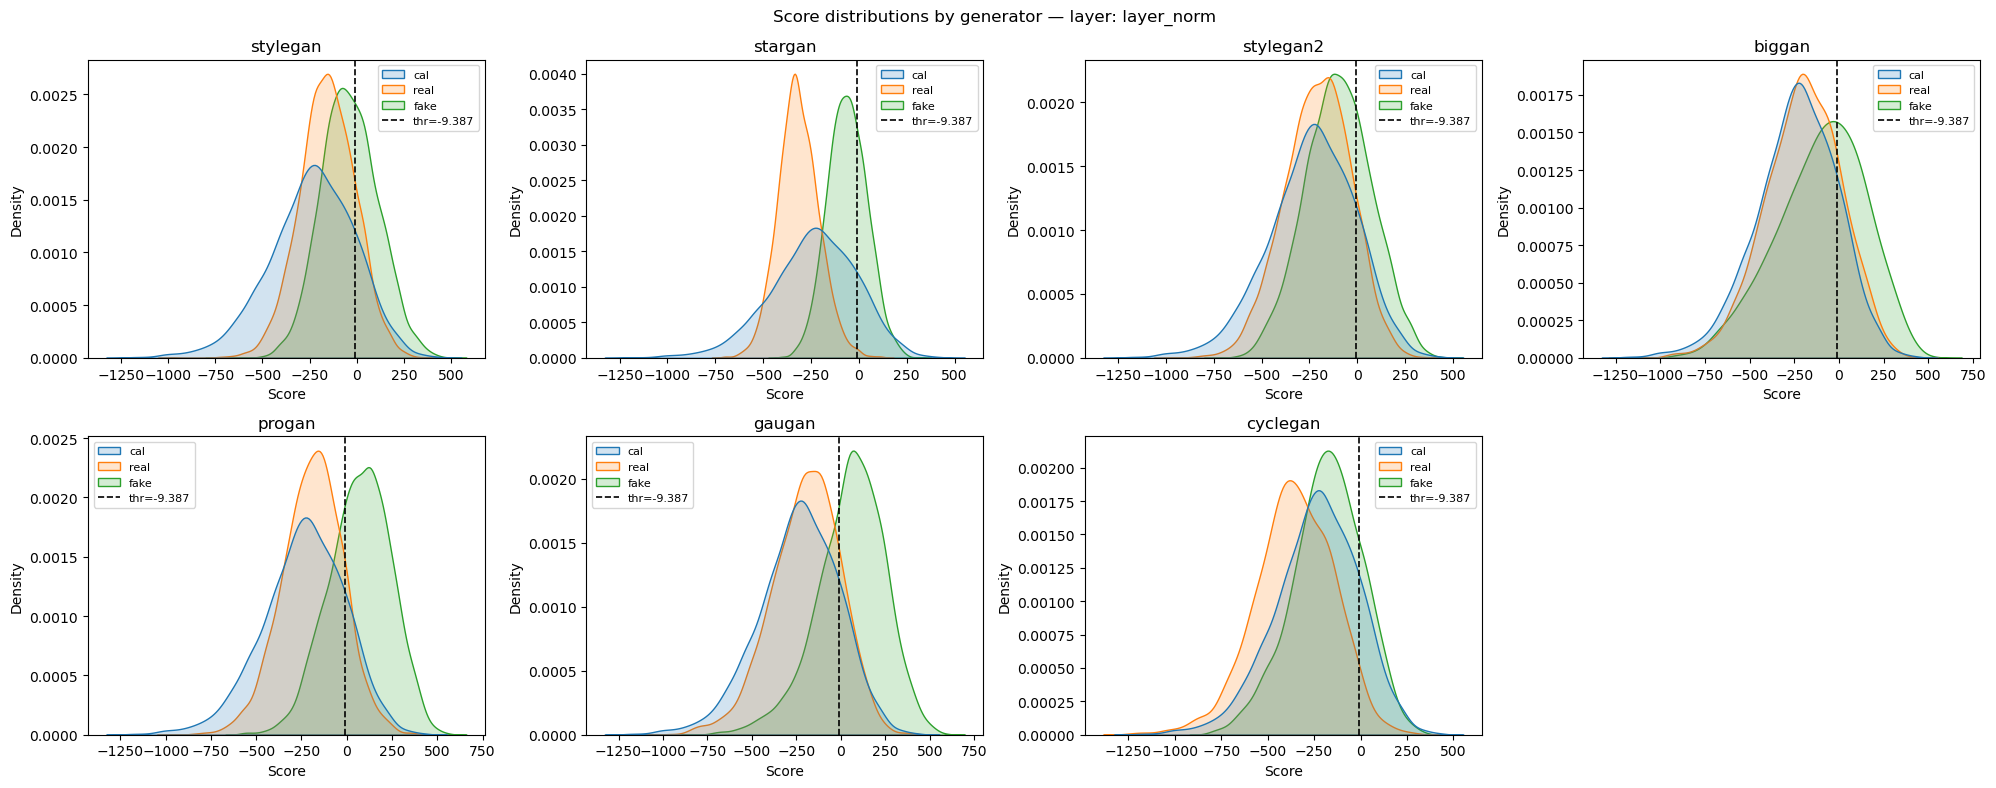

In [164]:
analyze_layer(clip_b16_ForenSynths_test_df, clip_b16_Imagenet5k_df, generators, "layer_norm")

Mean+std cal set threshold: 335.1023

stylegan      ACC:0.5078  AP:0.5185  AUC:0.5236  F1:0.2053
stargan       ACC:0.5405  AP:0.7593  AUC:0.7965  F1:0.1832
stylegan2     ACC:0.5095  AP:0.5141  AUC:0.5056  F1:0.1727
biggan        ACC:0.6240  AP:0.6887  AUC:0.6691  F1:0.5204
progan        ACC:0.8425  AP:0.9249  AUC:0.9108  F1:0.8393
gaugan        ACC:0.8232  AP:0.9098  AUC:0.9064  F1:0.8153
cyclegan      ACC:0.6866  AP:0.8538  AUC:0.8755  F1:0.5749

Macro-average AUC: 0.7411
Macro-average AP:  0.7384
Macro-average ACC: 0.6477
Macro-average F1:  0.4730


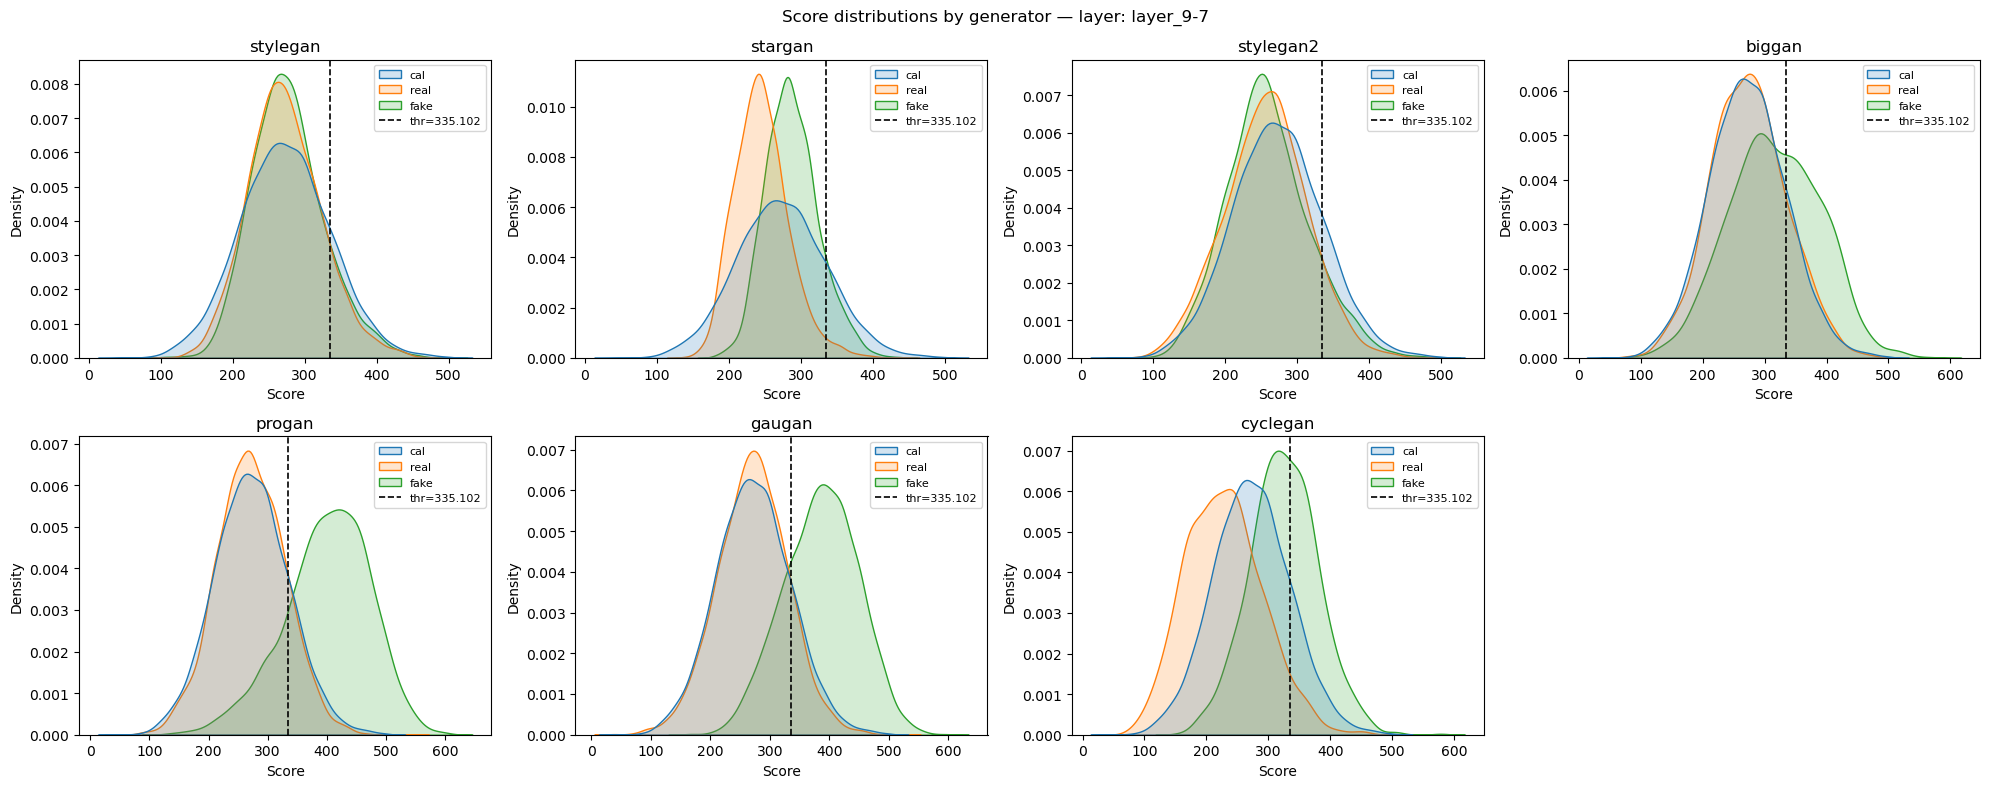

In [165]:
analyze_layer(clip_b16_ForenSynths_test_df, clip_b16_Imagenet5k_df, generators, "layer_9-7")

Mean+std cal set threshold: -9.3868

sd3                   ACC:0.4456  AP:0.3679  AUC:0.2714  F1:0.0616
flux                  ACC:0.4288  AP:0.3352  AUC:0.1712  F1:0.0049
sdxl                  ACC:0.4768  AP:0.4732  AUC:0.4926  F1:0.1588
dalle3                ACC:0.7170  AP:0.1158  AUC:0.3287  F1:0.0319
firefly               ACC:0.7243  AP:0.1267  AUC:0.3749  F1:0.0801
midjourney-v5         ACC:0.7180  AP:0.1255  AUC:0.3853  F1:0.0386
Macro-average AUC: 0.3373
Macro-average AP:  0.2574
Macro-average ACC: 0.5851
Macro-average F1:  0.0627


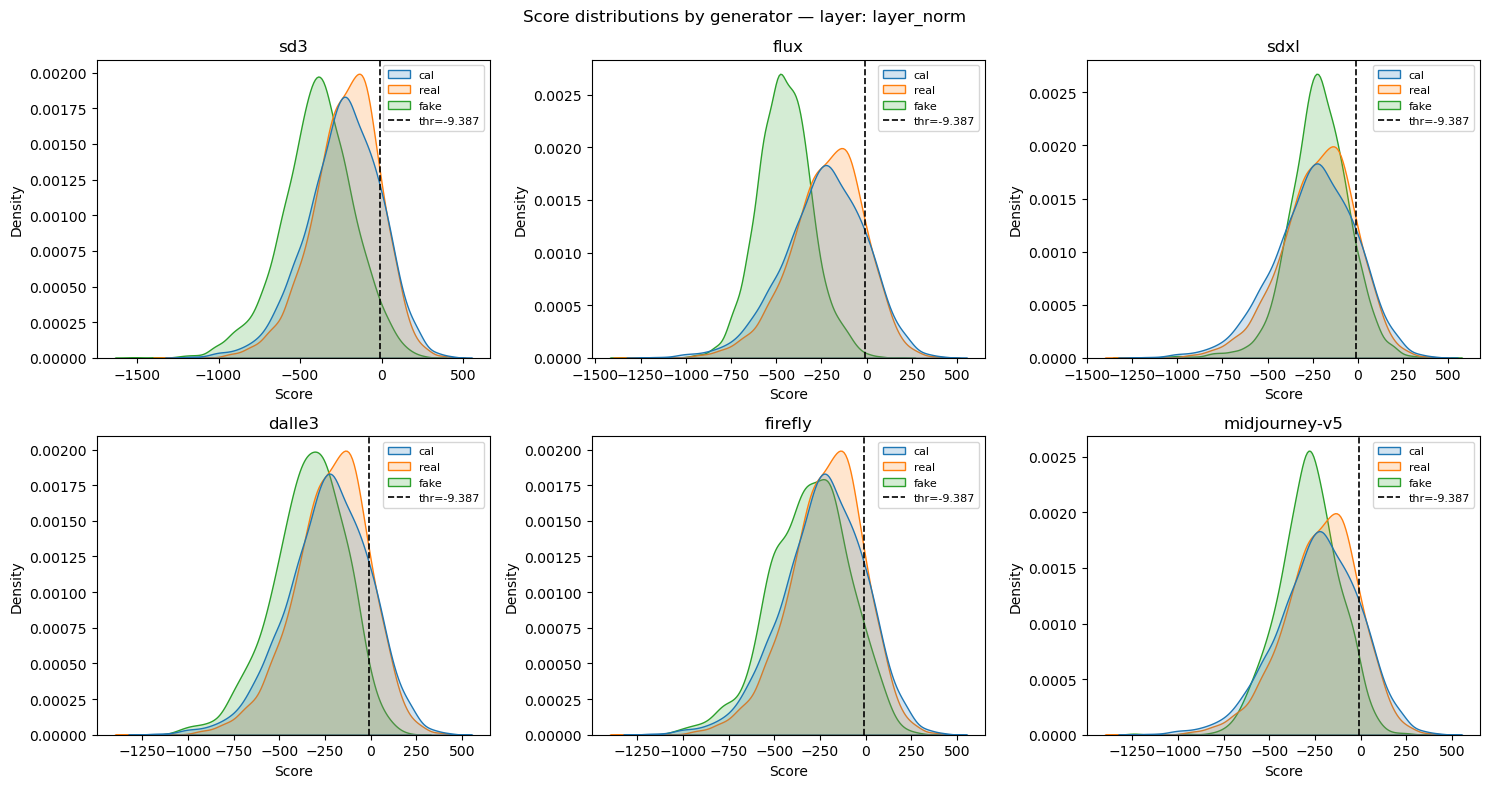

In [166]:
specific_layer_score_new_gen(clip_16_NewGenerators_test_df, "layer_norm", clip_b16_Imagenet5k_df)

Mean+std cal set threshold: 335.1023

sd3                   ACC:0.4603  AP:0.4112  AUC:0.3589  F1:0.1001
flux                  ACC:0.4348  AP:0.3549  AUC:0.2453  F1:0.0157
sdxl                  ACC:0.5235  AP:0.5632  AUC:0.5886  F1:0.2812
dalle3                ACC:0.7490  AP:0.2019  AUC:0.5727  F1:0.2023
firefly               ACC:0.7377  AP:0.1578  AUC:0.4778  F1:0.1352
midjourney-v5         ACC:0.7360  AP:0.1621  AUC:0.4819  F1:0.1249
Macro-average AUC: 0.4542
Macro-average AP:  0.3085
Macro-average ACC: 0.6069
Macro-average F1:  0.1432


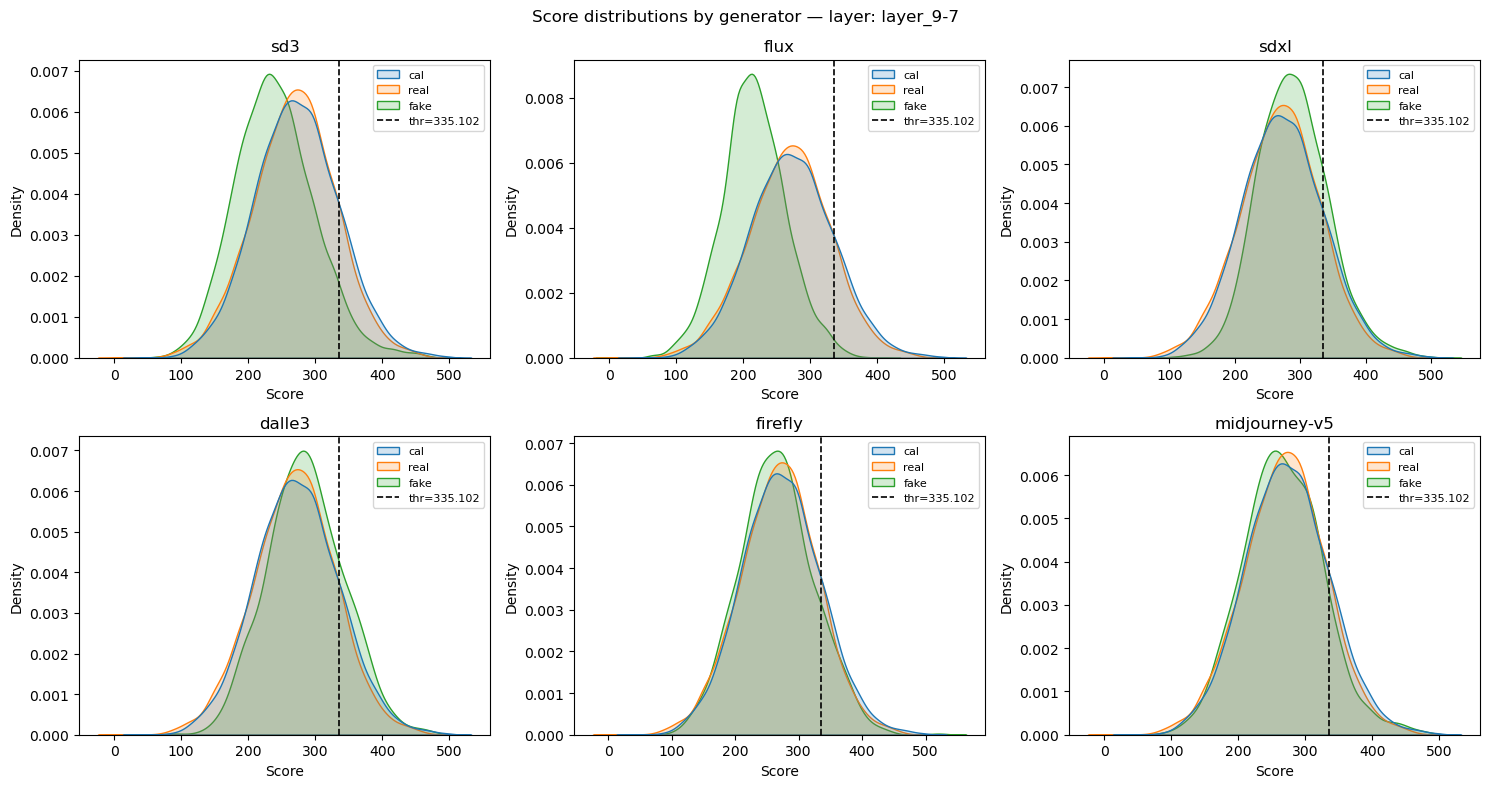

In [167]:
specific_layer_score_new_gen(clip_16_NewGenerators_test_df, "layer_9-7", clip_b16_Imagenet5k_df)

## Clip ViT-B32

In [168]:
clip_b32_ForenSynths_val_df = read_jsonl("/home/tischuet/zero-shot-deepfake-detection/outputs/vit_base_patch32_clip_224_openai/vit_base_patch32_clip_224_openai_layerwise_ForenSynths_val.jsonl")
clip_b32_Imagenet5k_cal_df = read_jsonl("/home/tischuet/zero-shot-deepfake-detection/outputs/vit_base_patch32_clip_224_openai/vit_base_patch32_clip_224_openai_layerwise_Imagenet_val_5k.jsonl")

clip_b32_ForenSynths_test_df = read_jsonl("/home/tischuet/zero-shot-deepfake-detection/outputs/vit_base_patch32_clip_224_openai/vit_base_patch32_clip_224_openai_layerwise_ForenSynths.jsonl")
clip_32_NewGenerator_test_df = read_jsonl("/home/tischuet/zero-shot-deepfake-detection/outputs/vit_base_patch32_clip_224_openai/vit_base_patch32_clip_224_openai_layerwise_New-Generator.jsonl")

AUC: [0.50708421875, 0.50576, 0.5107020624999999, 0.55060446875, 0.56885071875, 0.58653153125, 0.580197625, 0.6034503437500001, 0.63494459375, 0.7070665625, 0.73406959375, 0.7629085, 0.8202813750000001]
AP: [0.5039140002895235, 0.5026532694077476, 0.5049240644192581, 0.5378945258630294, 0.5648440050302375, 0.5904936890796068, 0.5770365535995898, 0.6085507942652338, 0.6394185085546703, 0.7141333188124508, 0.7411119263604148, 0.7686815038742772, 0.8300743774170869]


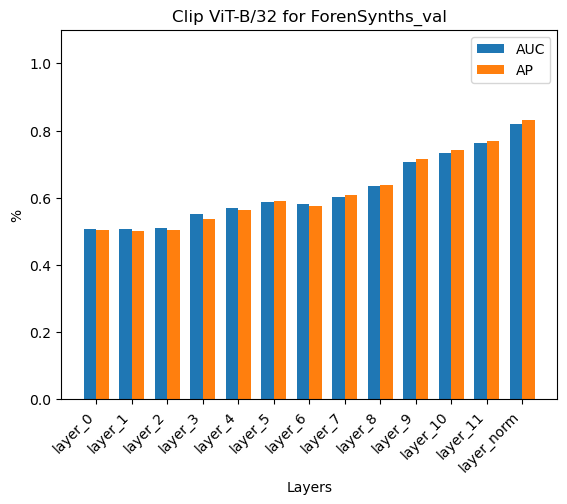

In [169]:
scores_layers(clip_b32_ForenSynths_val_df, "Clip ViT-B/32")

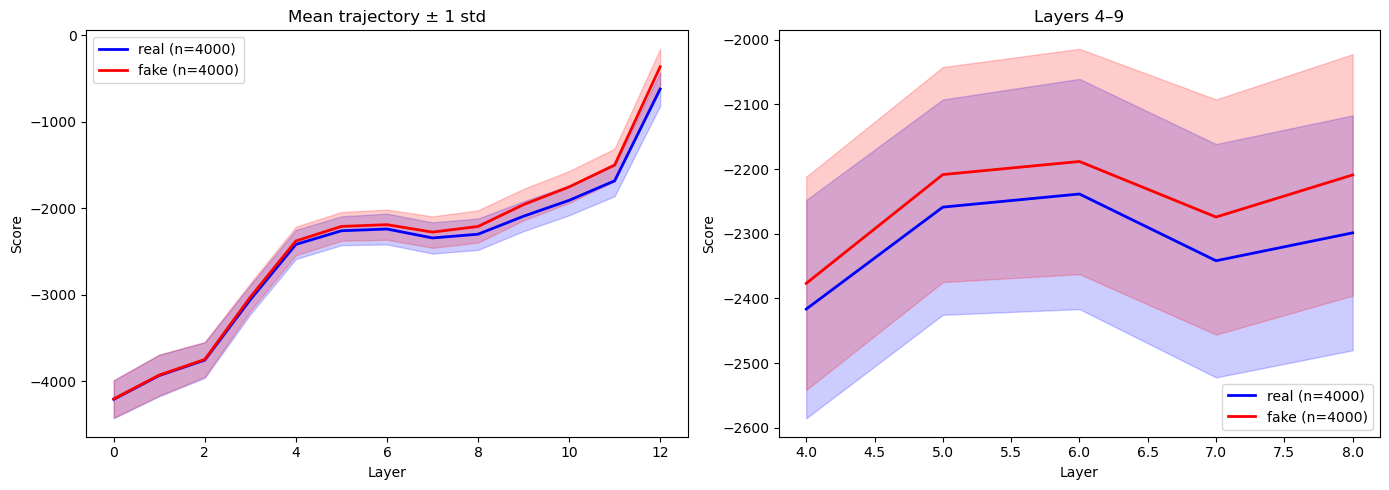

In [170]:
trajectory_plot(clip_b32_ForenSynths_val_df, (4,9), 12)

In [171]:
delta_mining(clip_b32_ForenSynths_val_df)

,delta,auc,ap
58,layer_11-3,0.789980,0.790494
59,layer_11-4,0.789856,0.790196
42,layer_9-6,0.786587,0.780645
49,layer_10-4,0.782179,0.794509
40,layer_9-4,0.781330,0.756476
...,...,...,...
9,layer_4-3,0.553647,0.561332
2,layer_2-1,0.518956,0.521400
1,layer_2-0,0.507440,0.509559
20,layer_6-5,0.500710,0.483078


In [172]:
clip_b32_Imagenet5k_cal_df["layer_11-3"] = clip_b32_Imagenet5k_cal_df["layer_11"] - clip_b32_Imagenet5k_cal_df["layer_3"]

clip_b32_ForenSynths_test_df["layer_9-7"] = clip_b32_ForenSynths_test_df["layer_9"] - clip_b32_ForenSynths_test_df["layer_7"]
clip_b32_ForenSynths_test_df["layer_11-3"] = clip_b32_ForenSynths_test_df["layer_11"] - clip_b32_ForenSynths_test_df["layer_3"]

clip_32_NewGenerator_test_df["layer_11-3"] = clip_32_NewGenerator_test_df["layer_11"] - clip_32_NewGenerator_test_df["layer_3"]

In [7]:
analyze_layer(clip_b32_ForenSynths_test_df, clip_b32_Imagenet5k_cal_df, generators, "layer_norm")

NameError: name 'clip_b32_ForenSynths_test_df' is not defined

Mean+std cal set threshold: 1483.7711

stylegan      ACC:0.4833  AP:0.4551  AUC:0.4268  F1:0.1308
stargan       ACC:0.5198  AP:0.7964  AUC:0.7966  F1:0.0822
stylegan2     ACC:0.4829  AP:0.4447  AUC:0.4095  F1:0.1349
biggan        ACC:0.5258  AP:0.5360  AUC:0.5223  F1:0.2966
progan        ACC:0.7149  AP:0.7844  AUC:0.7833  F1:0.6870
gaugan        ACC:0.6621  AP:0.7408  AUC:0.7489  F1:0.5771
cyclegan      ACC:0.6113  AP:0.7632  AUC:0.7916  F1:0.4141

Macro-average AUC: 0.6399
Macro-average AP:  0.6458
Macro-average ACC: 0.5714
Macro-average F1:  0.3318


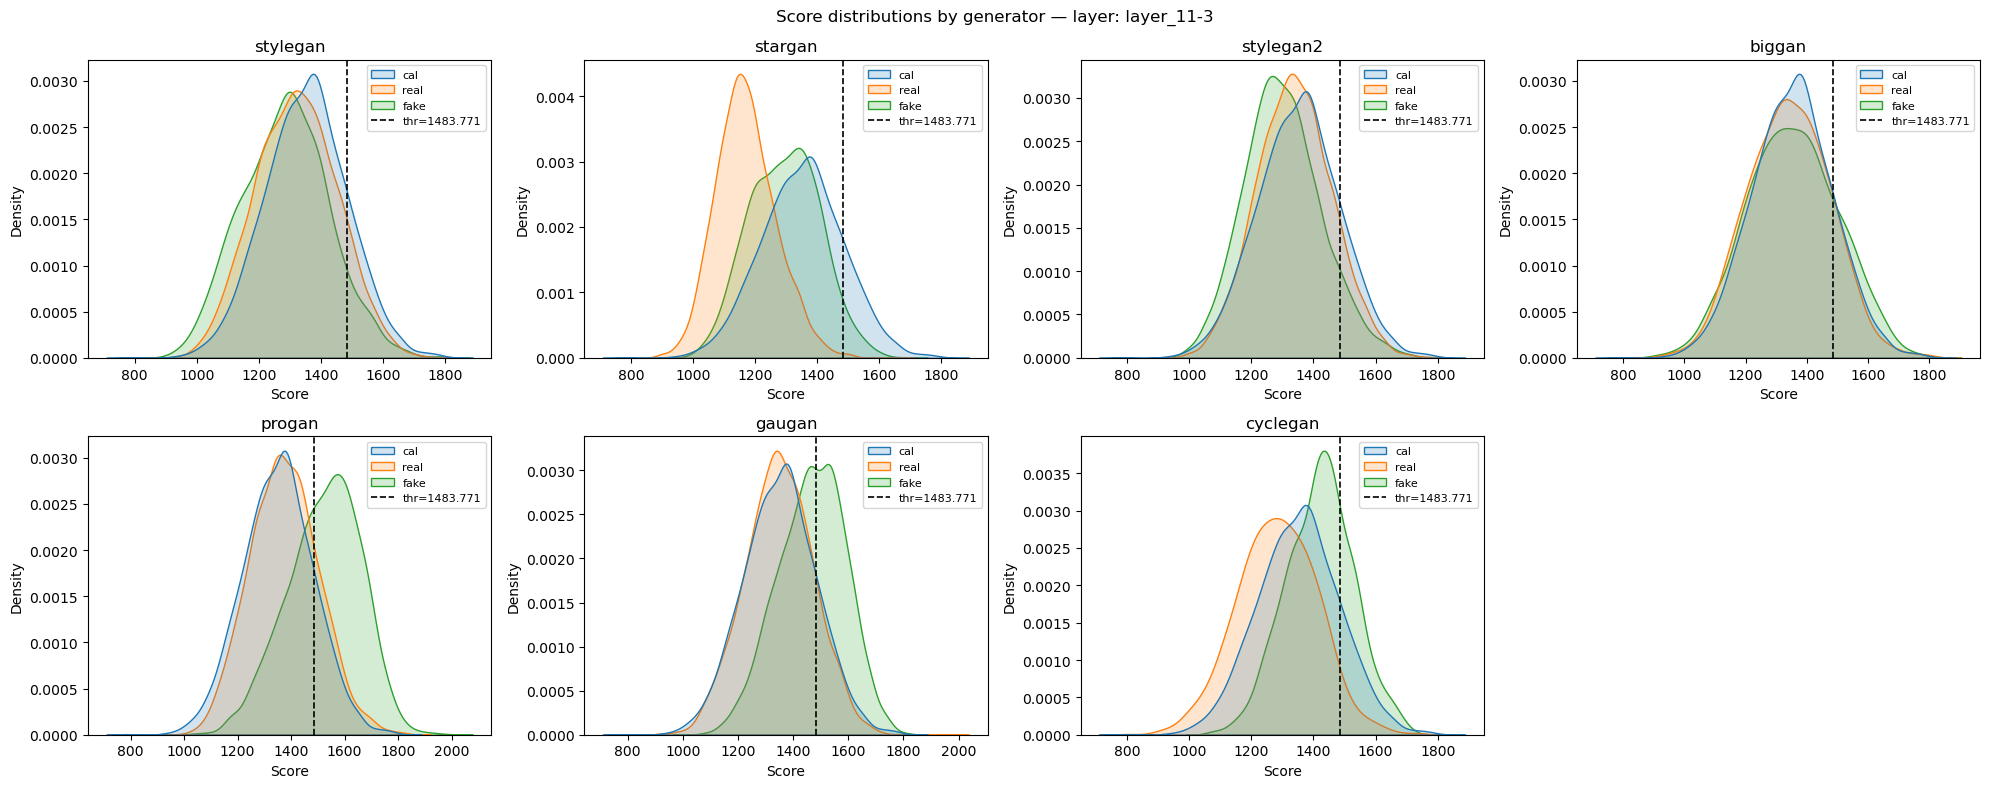

In [174]:
analyze_layer(clip_b32_ForenSynths_test_df, clip_b32_Imagenet5k_cal_df, generators, "layer_11-3")

Mean+std cal set threshold: -424.1997

sd3                   ACC:0.4384  AP:0.3420  AUC:0.1963  F1:0.0253
flux                  ACC:0.4327  AP:0.3346  AUC:0.1696  F1:0.0056
sdxl                  ACC:0.4970  AP:0.5117  AUC:0.5378  F1:0.2076
dalle3                ACC:0.7207  AP:0.1115  AUC:0.3014  F1:0.0153
firefly               ACC:0.7312  AP:0.1300  AUC:0.3905  F1:0.0861
midjourney-v5         ACC:0.7290  AP:0.1323  AUC:0.4124  F1:0.0719
Macro-average AUC: 0.3347
Macro-average AP:  0.2603
Macro-average ACC: 0.5915
Macro-average F1:  0.0686


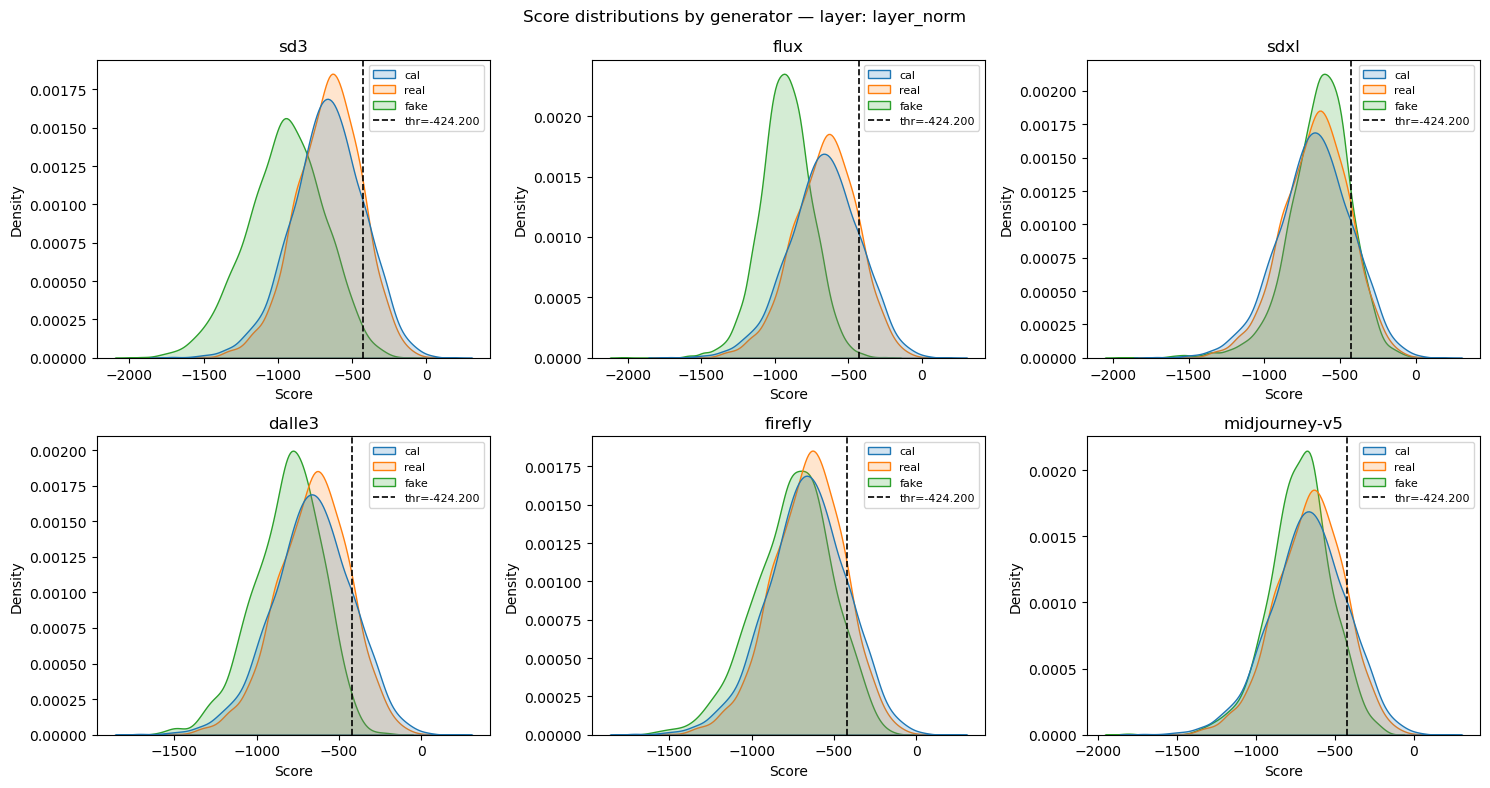

In [175]:
specific_layer_score_new_gen(clip_32_NewGenerator_test_df, "layer_norm", clip_b32_Imagenet5k_cal_df)

Mean+std cal set threshold: 1483.7711

sd3                   ACC:0.4542  AP:0.3588  AUC:0.2383  F1:0.0488
flux                  ACC:0.4415  AP:0.3184  AUC:0.0960  F1:0.0046
sdxl                  ACC:0.4575  AP:0.3844  AUC:0.3099  F1:0.0600
dalle3                ACC:0.7502  AP:0.1559  AUC:0.4691  F1:0.1167
firefly               ACC:0.7398  AP:0.1183  AUC:0.3386  F1:0.0453
midjourney-v5         ACC:0.7418  AP:0.1239  AUC:0.3626  F1:0.0595
Macro-average AUC: 0.3024
Macro-average AP:  0.2433
Macro-average ACC: 0.5975
Macro-average F1:  0.0558


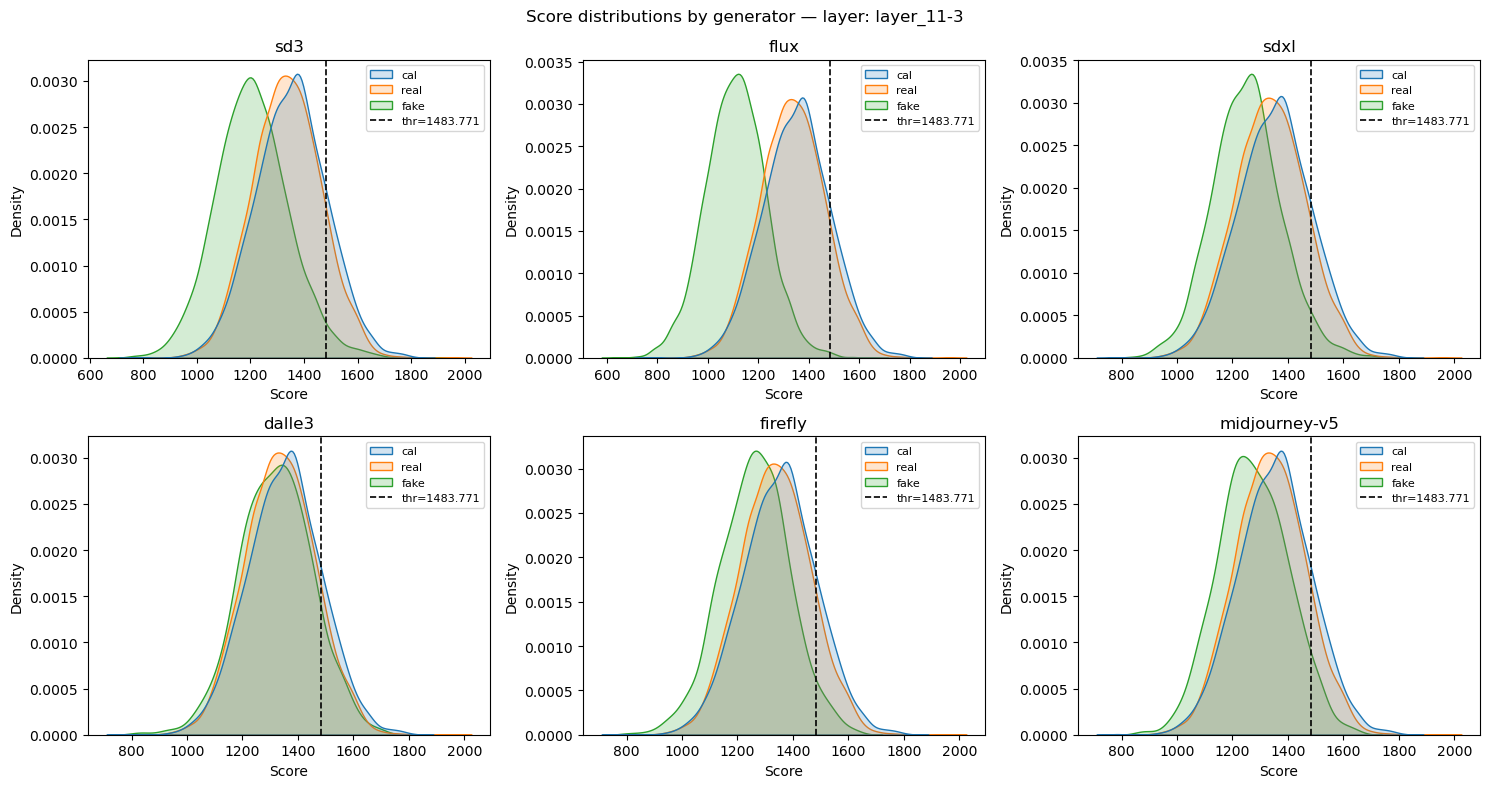

In [176]:
specific_layer_score_new_gen(clip_32_NewGenerator_test_df, "layer_11-3", clip_b32_Imagenet5k_cal_df)

## Metaclip ViT-B/16

In [177]:
metaclip_b16_ForenSynths_val_df = read_jsonl("/home/tischuet/zero-shot-deepfake-detection/outputs/vit_base_patch16_clip_quickgelu_224_metaclip_400m/vit_base_patch16_clip_quickgelu_224_metaclip_400m_layerwise_ForenSynths_val.jsonl")
metaclip_b16_Imagenet5k_cal_df = read_jsonl("/home/tischuet/zero-shot-deepfake-detection/outputs/vit_base_patch16_clip_quickgelu_224_metaclip_400m/vit_base_patch16_clip_quickgelu_224_metaclip_400m_layerwise_Imagenet_val_5k.jsonl")

metaclip_b16_ForenSynths_test_df = read_jsonl("/home/tischuet/zero-shot-deepfake-detection/outputs/vit_base_patch16_clip_quickgelu_224_metaclip_400m/vit_base_patch16_clip_quickgelu_224_metaclip_400m_layerwise_ForenSynths.jsonl")
metaclip_b16_NewGenerator_test_df = read_jsonl("/home/tischuet/zero-shot-deepfake-detection/outputs/vit_base_patch16_clip_quickgelu_224_metaclip_400m/vit_base_patch16_clip_quickgelu_224_metaclip_400m_layerwise_New-Generator.jsonl")

AUC: [0.51026221875, 0.513051375, 0.52894059375, 0.52645884375, 0.5065041875, 0.5193227812500001, 0.53676978125, 0.6608729375, 0.7413434375, 0.7926190625, 0.81855475, 0.82116065625, 0.8596755625]
AP: [0.5053313340388603, 0.506099506107217, 0.5181572183188067, 0.5219312758213113, 0.5160192730976259, 0.5250627777706977, 0.5417852851619528, 0.6680034705093374, 0.7615013865543155, 0.8113346159658228, 0.8353104124149962, 0.8311189813349109, 0.8691548744727431]


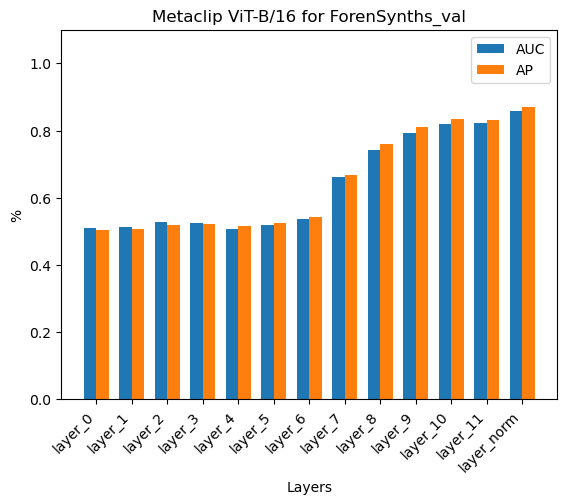

In [178]:
scores_layers(metaclip_b16_ForenSynths_val_df, "Metaclip ViT-B/16")

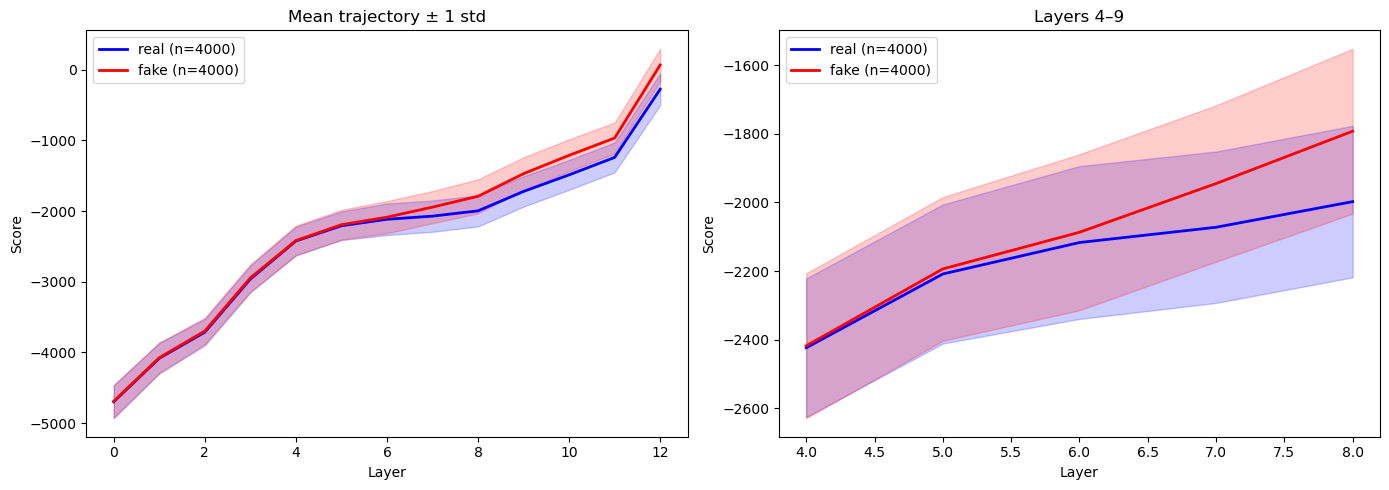

In [179]:
trajectory_plot(metaclip_b16_ForenSynths_val_df, (4,9), 12)

In [180]:
delta_mining(metaclip_b16_ForenSynths_val_df)

,delta,auc,ap
27,layer_7-6,0.970360,0.974343
34,layer_8-6,0.961693,0.958076
33,layer_8-5,0.949659,0.952699
42,layer_9-6,0.946469,0.948993
32,layer_8-4,0.945757,0.949767
...,...,...,...
7,layer_4-1,0.483239,0.510836
12,layer_5-2,0.475579,0.508819
13,layer_5-3,0.473593,0.497498
8,layer_4-2,0.453574,0.495615


In [181]:
metaclip_b16_Imagenet5k_cal_df["layer_7-6"] = metaclip_b16_Imagenet5k_cal_df["layer_7"] - metaclip_b16_Imagenet5k_cal_df["layer_6"]
metaclip_b16_ForenSynths_test_df["layer_7-6"] = metaclip_b16_ForenSynths_test_df["layer_7"] - metaclip_b16_ForenSynths_test_df["layer_6"]
metaclip_b16_NewGenerator_test_df["layer_7-6"] = metaclip_b16_NewGenerator_test_df["layer_7"] - metaclip_b16_NewGenerator_test_df["layer_6"]

Mean+std cal set threshold: -31.7639

stylegan      ACC:0.6527  AP:0.7427  AUC:0.7315  F1:0.5406
stargan       ACC:0.7351  AP:0.9791  AUC:0.9784  F1:0.6404
stylegan2     ACC:0.5794  AP:0.6801  AUC:0.6825  F1:0.3561
biggan        ACC:0.6118  AP:0.6521  AUC:0.6127  F1:0.5208
progan        ACC:0.7689  AP:0.8626  AUC:0.8517  F1:0.7452
gaugan        ACC:0.7602  AP:0.8503  AUC:0.8334  F1:0.7508
cyclegan      ACC:0.6147  AP:0.7630  AUC:0.7794  F1:0.4369

Macro-average AUC: 0.7814
Macro-average AP:  0.7900
Macro-average ACC: 0.6747
Macro-average F1:  0.5701


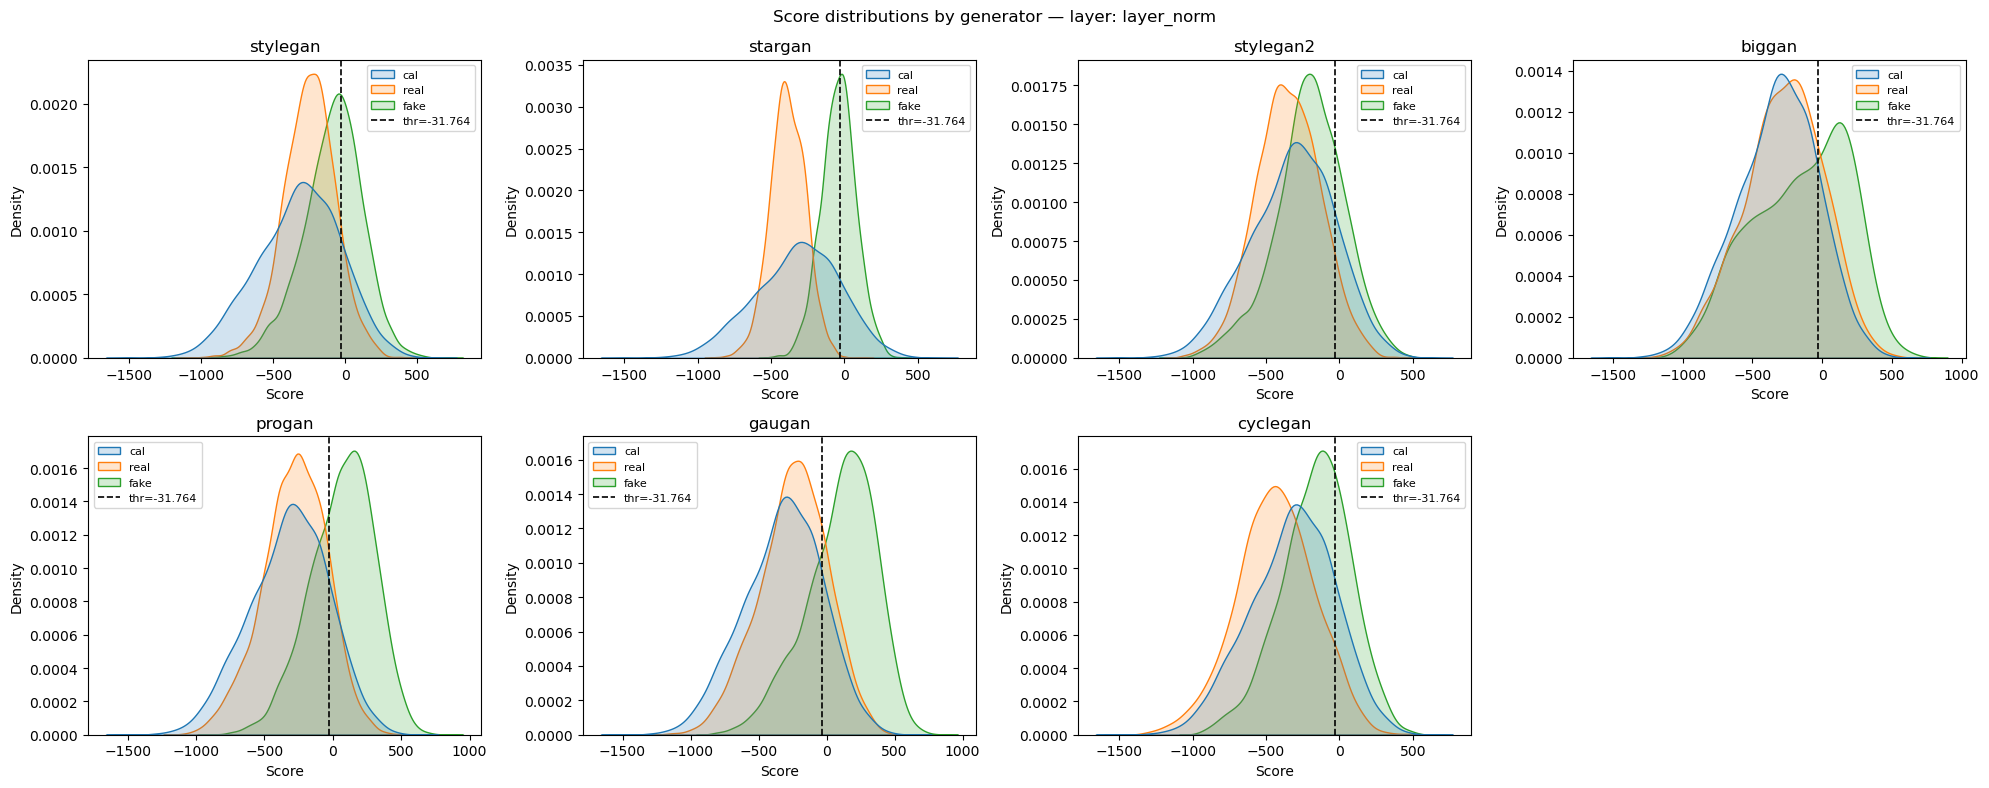

In [182]:
analyze_layer(metaclip_b16_ForenSynths_test_df, metaclip_b16_Imagenet5k_cal_df, generators, "layer_norm")

Mean+std cal set threshold: 85.3789

stylegan      ACC:0.6738  AP:0.8098  AUC:0.8057  F1:0.5622
stargan       ACC:0.8754  AP:0.9464  AUC:0.9474  F1:0.8770
stylegan2     ACC:0.6019  AP:0.6980  AUC:0.6959  F1:0.4125
biggan        ACC:0.8107  AP:0.8877  AUC:0.8967  F1:0.8126
progan        ACC:0.9105  AP:0.9731  AUC:0.9693  F1:0.9117
gaugan        ACC:0.9029  AP:0.9741  AUC:0.9744  F1:0.9081
cyclegan      ACC:0.9152  AP:0.9784  AUC:0.9778  F1:0.9185

Macro-average AUC: 0.8953
Macro-average AP:  0.8954
Macro-average ACC: 0.8129
Macro-average F1:  0.7718


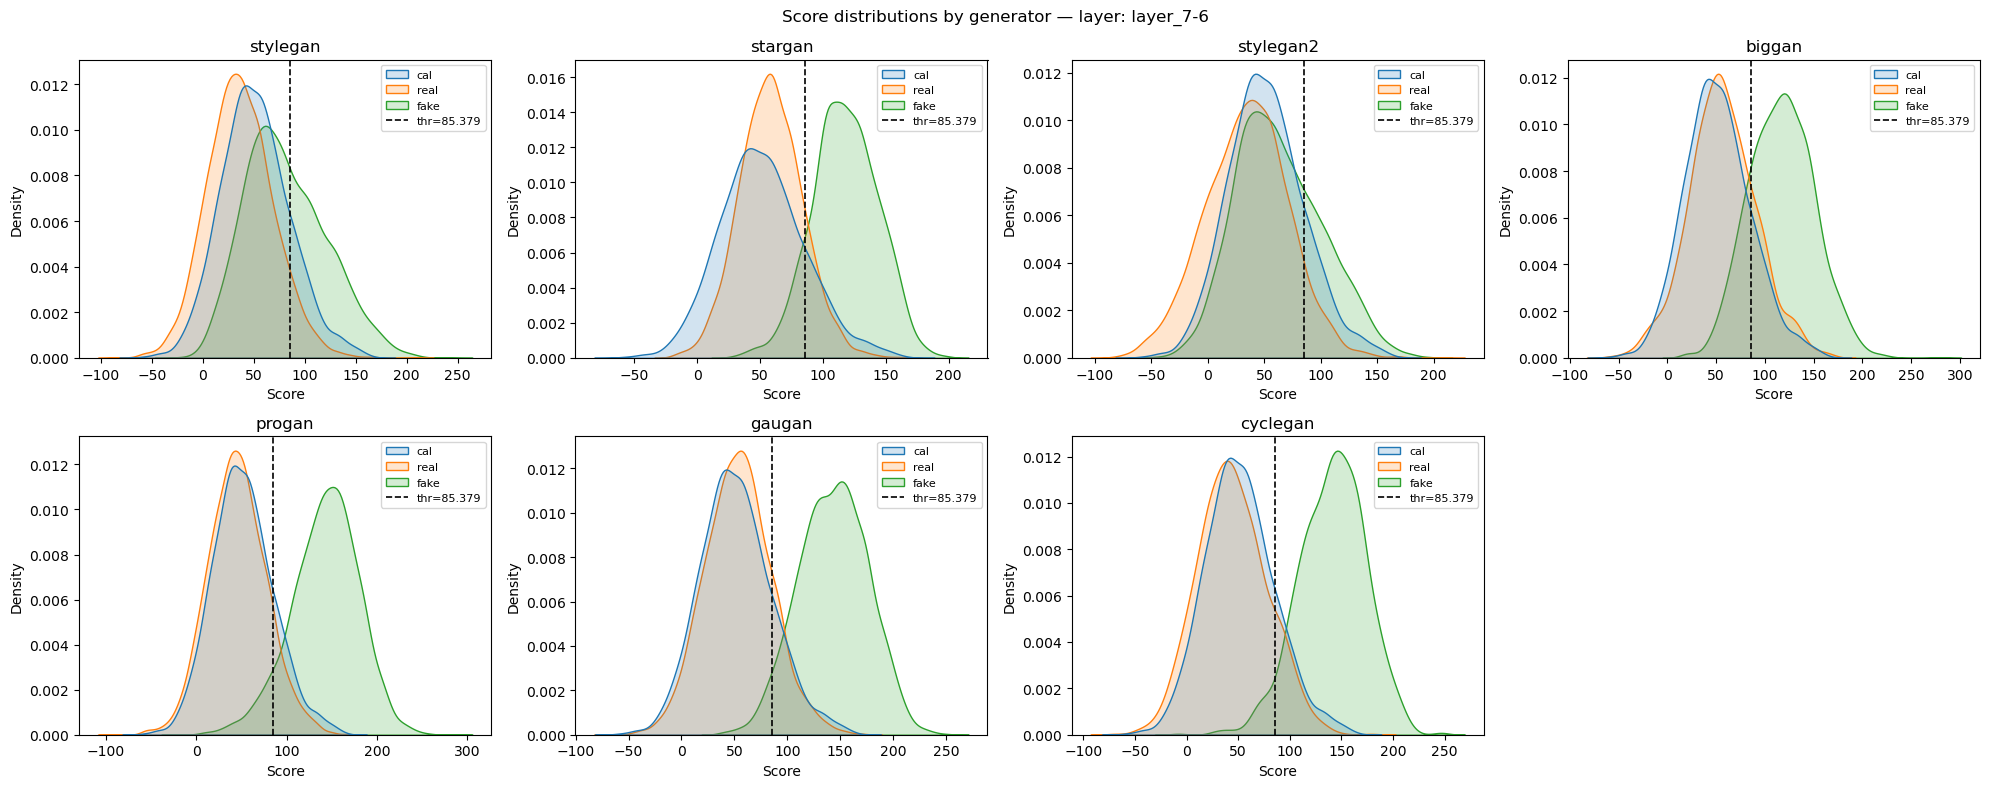

In [183]:
analyze_layer(metaclip_b16_ForenSynths_test_df, metaclip_b16_Imagenet5k_cal_df, generators, "layer_7-6")

Mean+std cal set threshold: -31.7639

sd3                   ACC:0.4594  AP:0.4266  AUC:0.3851  F1:0.1481
flux                  ACC:0.4243  AP:0.3715  AUC:0.2970  F1:0.0397
sdxl                  ACC:0.4993  AP:0.5050  AUC:0.5183  F1:0.2577
dalle3                ACC:0.6908  AP:0.1105  AUC:0.2940  F1:0.0221
firefly               ACC:0.7040  AP:0.1397  AUC:0.4347  F1:0.1012
midjourney-v5         ACC:0.6988  AP:0.1280  AUC:0.3977  F1:0.0710
Macro-average AUC: 0.3878
Macro-average AP:  0.2802
Macro-average ACC: 0.5794
Macro-average F1:  0.1066


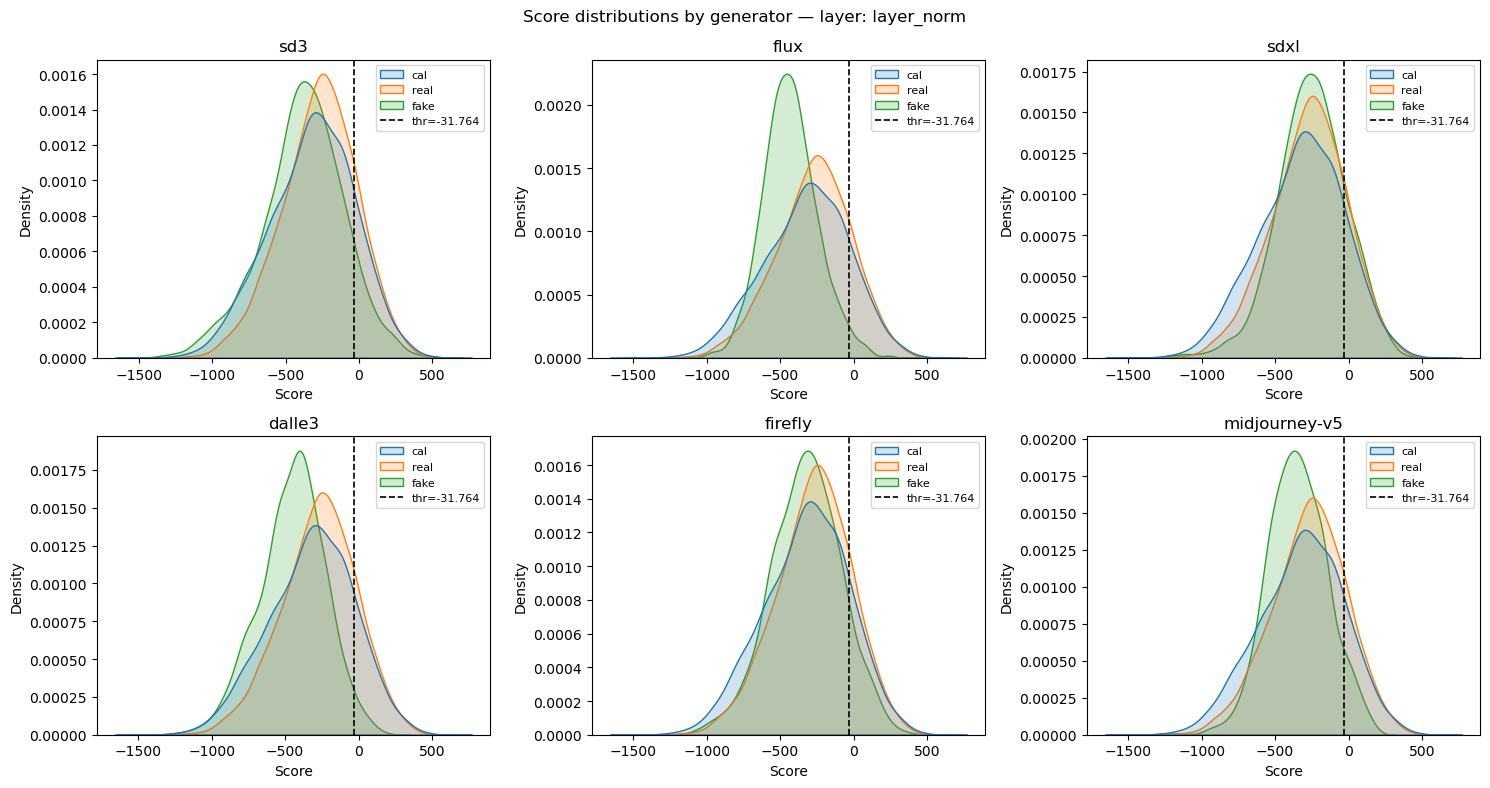

In [184]:
specific_layer_score_new_gen(metaclip_b16_NewGenerator_test_df, "layer_norm", metaclip_b16_Imagenet5k_cal_df)

Mean+std cal set threshold: 85.3789

sd3                   ACC:0.6494  AP:0.7387  AUC:0.7540  F1:0.5416
flux                  ACC:0.4481  AP:0.3435  AUC:0.2034  F1:0.0206
sdxl                  ACC:0.5583  AP:0.6181  AUC:0.6164  F1:0.3444
dalle3                ACC:0.7618  AP:0.1840  AUC:0.5362  F1:0.1716
firefly               ACC:0.7630  AP:0.1934  AUC:0.5356  F1:0.1790
midjourney-v5         ACC:0.7542  AP:0.1569  AUC:0.4794  F1:0.1215
Macro-average AUC: 0.5208
Macro-average AP:  0.3724
Macro-average ACC: 0.6558
Macro-average F1:  0.2298


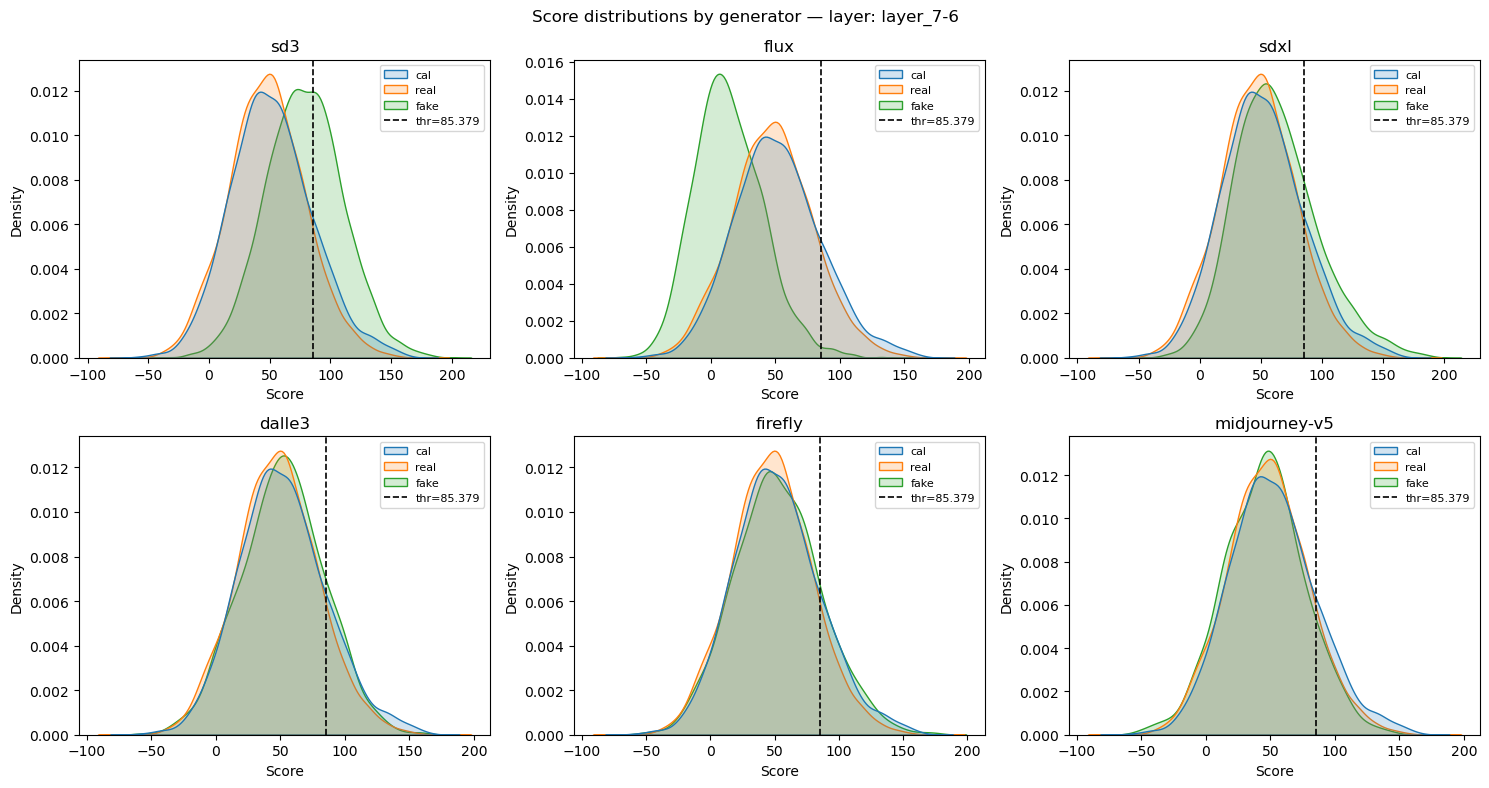

In [185]:
specific_layer_score_new_gen(metaclip_b16_NewGenerator_test_df, "layer_7-6", metaclip_b16_Imagenet5k_cal_df)

## Metaclip ViT-B/32

In [186]:
metaclip_b32_ForenSynths_val_df = read_jsonl("/home/tischuet/zero-shot-deepfake-detection/outputs/vit_base_patch32_clip_quickgelu_224_metaclip_400m/vit_base_patch32_clip_quickgelu_224_metaclip_400m_layerwise_ForenSynths_val.jsonl")
metaclip_b32_Imagenet5k_cal_df = read_jsonl("/home/tischuet/zero-shot-deepfake-detection/outputs/vit_base_patch32_clip_quickgelu_224_metaclip_400m/vit_base_patch32_clip_quickgelu_224_metaclip_400m_layerwise_Imagenet_val_5k.jsonl")

metaclip_b32_ForenSynths_test_df = read_jsonl("/home/tischuet/zero-shot-deepfake-detection/outputs/vit_base_patch32_clip_quickgelu_224_metaclip_400m/vit_base_patch32_clip_quickgelu_224_metaclip_400m_layerwise_ForenSynths.jsonl")
metaclip_32_NewGenerator_test_df = read_jsonl("/home/tischuet/zero-shot-deepfake-detection/outputs/vit_base_patch32_clip_quickgelu_224_metaclip_400m/vit_base_patch32_clip_quickgelu_224_metaclip_400m_layerwise_New-Generator.jsonl")

AUC: [0.5081155, 0.50556359375, 0.5281814375, 0.534594875, 0.5310225000000001, 0.536863625, 0.551175, 0.58820975, 0.645912, 0.6811047499999999, 0.7057535, 0.71929571875, 0.77677971875]
AP: [0.5050046813822653, 0.5027725024736182, 0.5162547724316289, 0.5280123309173914, 0.5354610743401413, 0.5438468213762202, 0.5572079938121033, 0.5980679723089555, 0.6572367092857936, 0.6907077575273802, 0.7112353510921696, 0.7234905400564139, 0.7823429903696033]


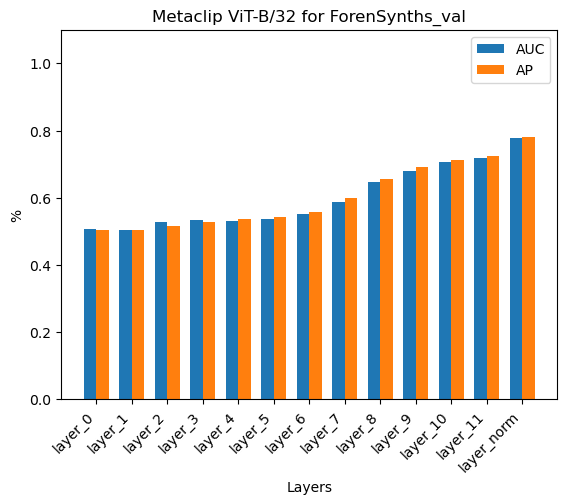

In [187]:
scores_layers(metaclip_b32_ForenSynths_val_df, "Metaclip ViT-B/32")

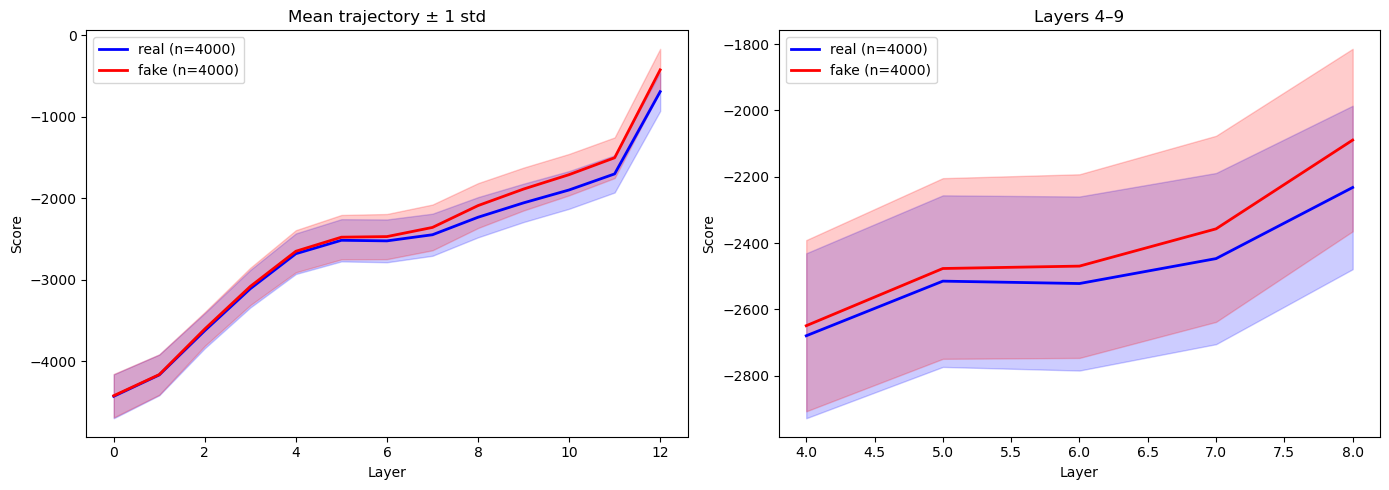

In [188]:
trajectory_plot(metaclip_b32_ForenSynths_val_df, (4,9), 12)

In [189]:
delta_mining(metaclip_b32_ForenSynths_val_df)

,delta,auc,ap
34,layer_8-6,0.872496,0.867337
33,layer_8-5,0.863274,0.852396
32,layer_8-4,0.859333,0.829280
40,layer_9-4,0.846327,0.834971
27,layer_7-6,0.842054,0.800646
...,...,...,...
12,layer_5-2,0.516312,0.536227
5,layer_3-2,0.505260,0.534764
8,layer_4-2,0.496781,0.526821
9,layer_4-3,0.491599,0.513809


In [190]:
metaclip_b32_Imagenet5k_cal_df["layer_8-6"] = metaclip_b32_Imagenet5k_cal_df["layer_8"] - metaclip_b32_Imagenet5k_cal_df["layer_6"]
metaclip_b32_ForenSynths_test_df["layer_8-6"] = metaclip_b32_ForenSynths_test_df["layer_8"] - metaclip_b32_ForenSynths_test_df["layer_6"]
metaclip_32_NewGenerator_test_df["layer_8-6"] = metaclip_32_NewGenerator_test_df["layer_8"] - metaclip_32_NewGenerator_test_df["layer_6"]

Mean+std cal set threshold: -439.6324

stylegan      ACC:0.6052  AP:0.6701  AUC:0.6625  F1:0.4795
stargan       ACC:0.7579  AP:0.9120  AUC:0.9085  F1:0.6977
stylegan2     ACC:0.5848  AP:0.6770  AUC:0.6966  F1:0.3971
biggan        ACC:0.5747  AP:0.5977  AUC:0.5524  F1:0.4328
progan        ACC:0.6887  AP:0.7792  AUC:0.7736  F1:0.6329
gaugan        ACC:0.7225  AP:0.8089  AUC:0.8107  F1:0.6814
cyclegan      ACC:0.5848  AP:0.6748  AUC:0.7007  F1:0.3989

Macro-average AUC: 0.7293
Macro-average AP:  0.7314
Macro-average ACC: 0.6455
Macro-average F1:  0.5315


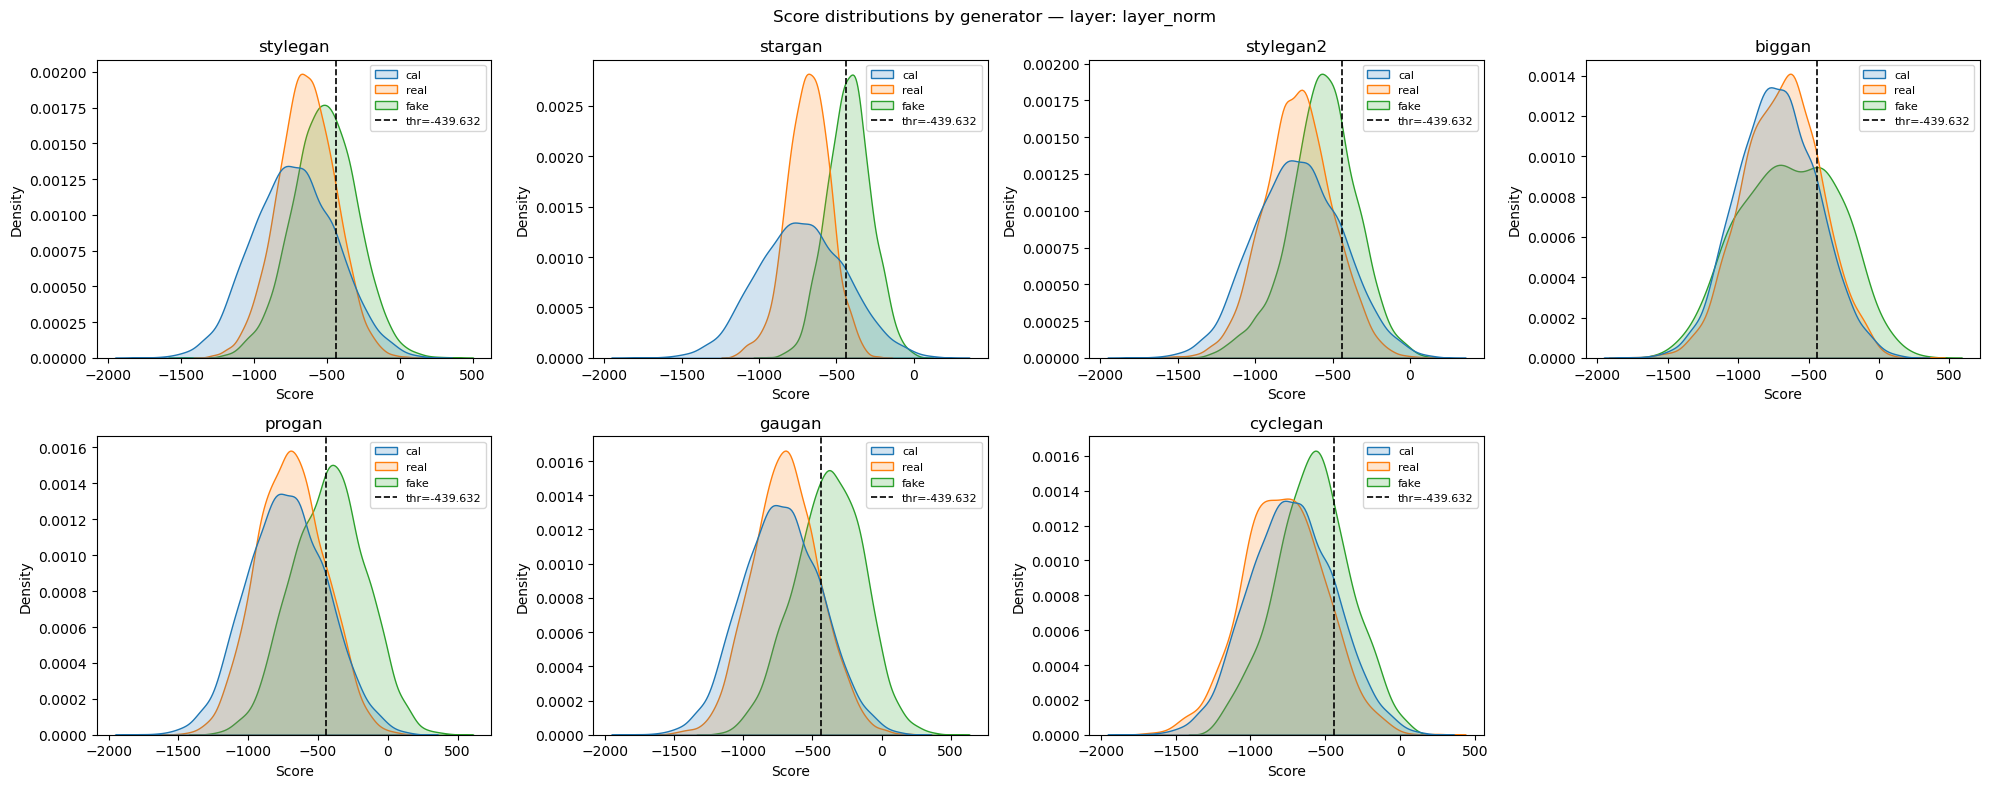

In [191]:
analyze_layer(metaclip_b32_ForenSynths_test_df, metaclip_b32_Imagenet5k_cal_df, generators, "layer_norm")

Mean+std cal set threshold: 341.4436

stylegan      ACC:0.5046  AP:0.5343  AUC:0.5630  F1:0.1594
stargan       ACC:0.6143  AP:0.6508  AUC:0.6674  F1:0.5380
stylegan2     ACC:0.4879  AP:0.4866  AUC:0.5083  F1:0.1003
biggan        ACC:0.5857  AP:0.6296  AUC:0.6372  F1:0.4245
progan        ACC:0.7915  AP:0.8674  AUC:0.8727  F1:0.7833
gaugan        ACC:0.7211  AP:0.8059  AUC:0.8230  F1:0.6751
cyclegan      ACC:0.8304  AP:0.9422  AUC:0.9437  F1:0.8066

Macro-average AUC: 0.7165
Macro-average AP:  0.7024
Macro-average ACC: 0.6479
Macro-average F1:  0.4982


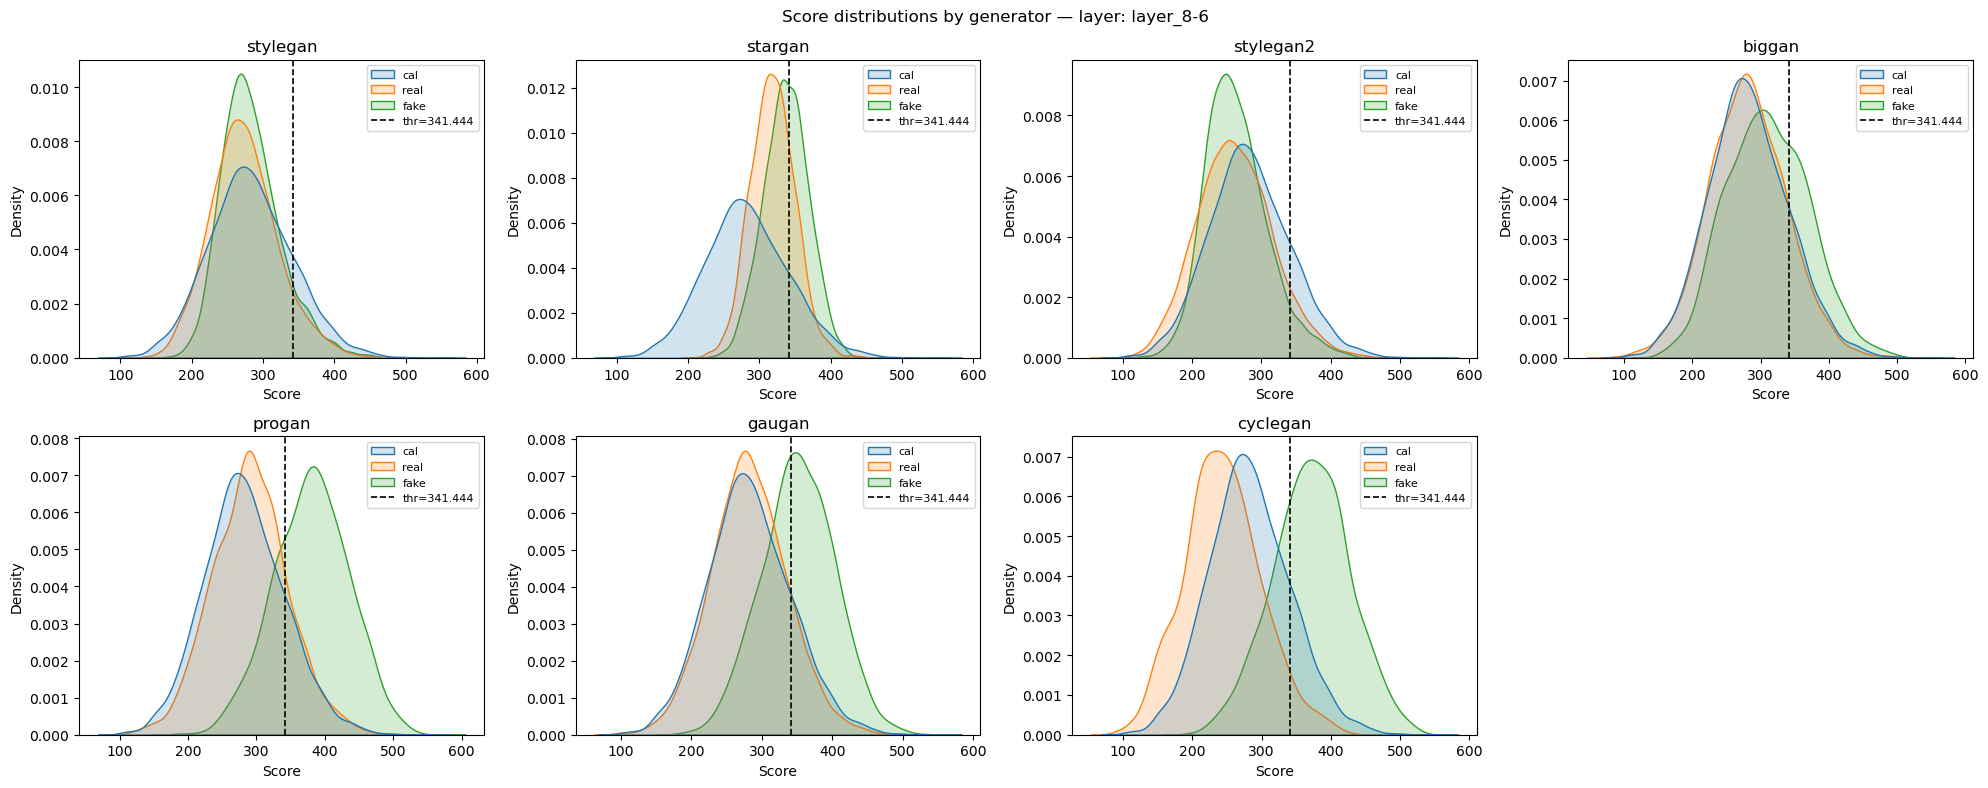

In [192]:
analyze_layer(metaclip_b32_ForenSynths_test_df, metaclip_b32_Imagenet5k_cal_df, generators, "layer_8-6")

Mean+std cal set threshold: -439.6324

sd3                   ACC:0.4561  AP:0.3779  AUC:0.2766  F1:0.0949
flux                  ACC:0.4459  AP:0.3762  AUC:0.2974  F1:0.0620
sdxl                  ACC:0.5024  AP:0.5085  AUC:0.5281  F1:0.2311
dalle3                ACC:0.7153  AP:0.1060  AUC:0.2596  F1:0.0184
firefly               ACC:0.7280  AP:0.1392  AUC:0.4192  F1:0.1013
midjourney-v5         ACC:0.7255  AP:0.1371  AUC:0.4279  F1:0.0855
Macro-average AUC: 0.3681
Macro-average AP:  0.2741
Macro-average ACC: 0.5955
Macro-average F1:  0.0989


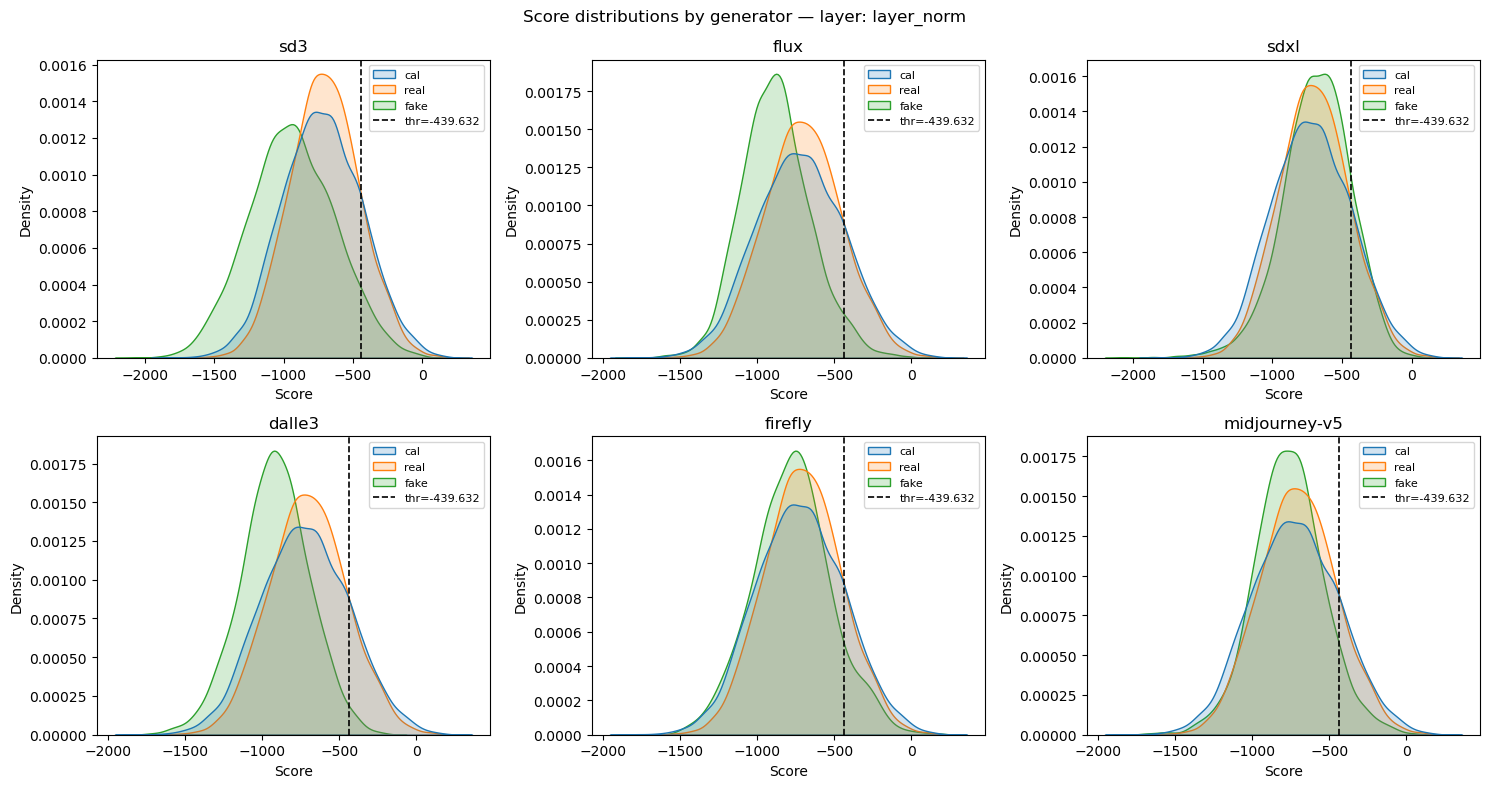

In [193]:
specific_layer_score_new_gen(metaclip_32_NewGenerator_test_df, "layer_norm", metaclip_b32_Imagenet5k_cal_df)

Mean+std cal set threshold: 341.4436

sd3                   ACC:0.4933  AP:0.5151  AUC:0.5457  F1:0.1773
flux                  ACC:0.4434  AP:0.3648  AUC:0.2750  F1:0.0166
sdxl                  ACC:0.5049  AP:0.5128  AUC:0.5090  F1:0.2110
dalle3                ACC:0.7637  AP:0.2164  AUC:0.5946  F1:0.2157
firefly               ACC:0.7428  AP:0.1294  AUC:0.3736  F1:0.0832
midjourney-v5         ACC:0.7428  AP:0.1321  AUC:0.3961  F1:0.0832
Macro-average AUC: 0.4490
Macro-average AP:  0.3118
Macro-average ACC: 0.6152
Macro-average F1:  0.1312


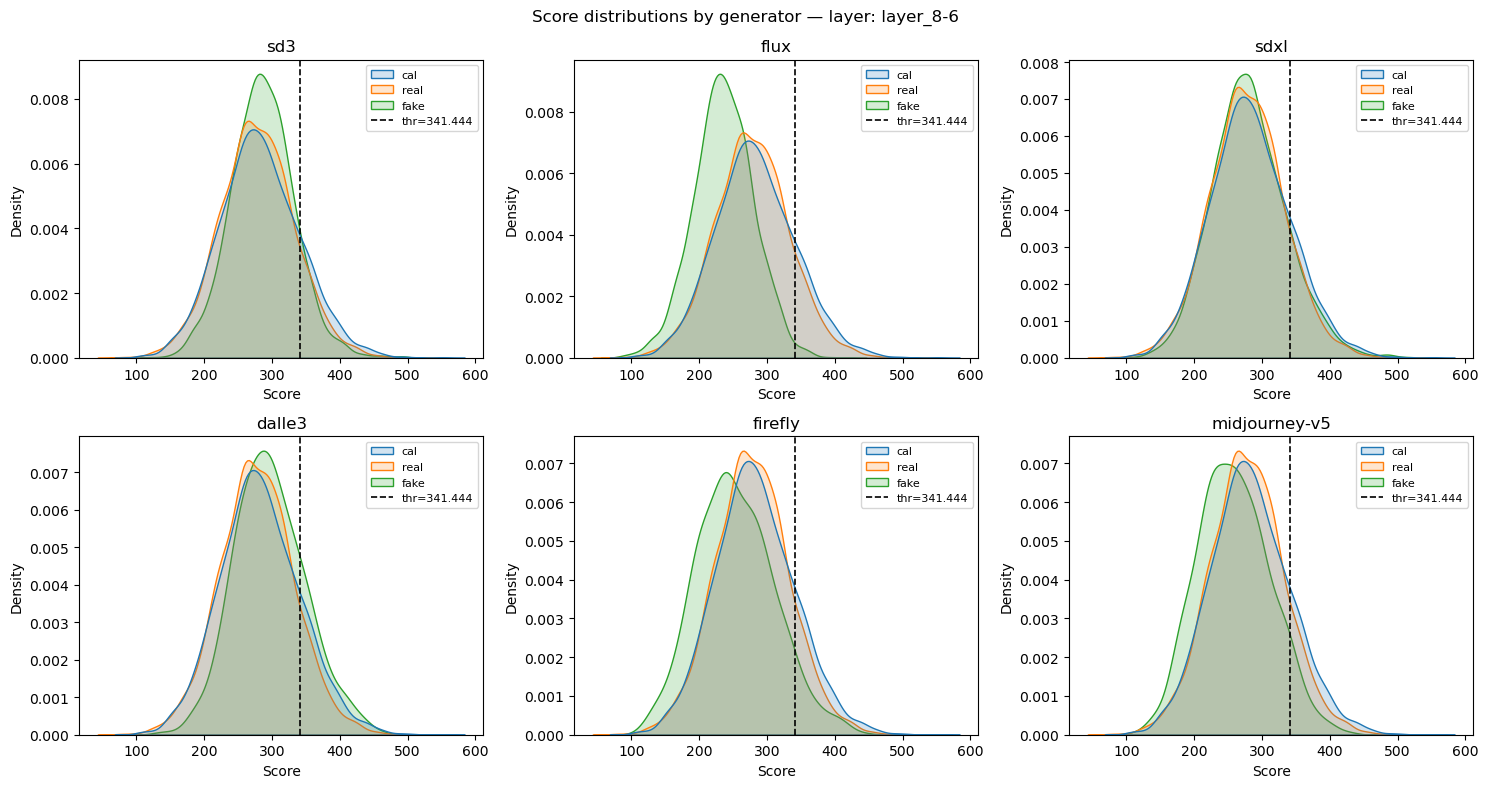

In [194]:
specific_layer_score_new_gen(metaclip_32_NewGenerator_test_df, "layer_8-6", metaclip_b32_Imagenet5k_cal_df)

## Clip ViT-L/14

In [195]:
clip_l14_ForenSynths_val_df = read_jsonl("/home/tischuet/zero-shot-deepfake-detection/outputs/vit_large_patch14_clip_224_openai/vit_large_patch14_clip_224_openai_layerwise_ForenSynths_val.jsonl")
clip_l14_Imagenet5k_cal_df = read_jsonl("/home/tischuet/zero-shot-deepfake-detection/outputs/vit_large_patch14_clip_224_openai/vit_large_patch14_clip_224_openai_layerwise_Imagenet_val_5k.jsonl")

clip_l14_ForenSynths_test_df = read_jsonl("/home/tischuet/zero-shot-deepfake-detection/outputs/vit_large_patch14_clip_224_openai/vit_large_patch14_clip_224_openai_layerwise_ForenSynths.jsonl")
clip_l14_NewGenerator_test_df = read_jsonl("/home/tischuet/zero-shot-deepfake-detection/outputs/vit_large_patch14_clip_224_openai/vit_large_patch14_clip_224_openai_layerwise_New-Generator.jsonl")

AUC: [0.514667625, 0.5139265, 0.51233696875, 0.5148790625, 0.5201746875, 0.51994090625, 0.55611765625, 0.5853174375, 0.62116846875, 0.5921465937499999, 0.61047890625, 0.593641125, 0.55913365625, 0.65416075, 0.72146421875, 0.81911015625, 0.8559125, 0.86681653125, 0.8883362187499999, 0.8647358124999999, 0.84599490625, 0.87521703125, 0.86237740625, 0.85259025, 0.8377531250000001]
AP: [0.5094131415304146, 0.5078989950381647, 0.5064870887805288, 0.5091125302791223, 0.5153916294763807, 0.5163031142775478, 0.5541686738265641, 0.579365536227811, 0.6147562918585034, 0.5875566169804323, 0.6127733905414616, 0.6070082019810003, 0.5816482070476408, 0.6766419555524082, 0.7477742847237617, 0.8347312812001082, 0.8665846401319278, 0.8784055462214935, 0.90144027077356, 0.8812930993818964, 0.8637988244347492, 0.8909572007868506, 0.8757195803984686, 0.8608574479461634, 0.8414069473705106]


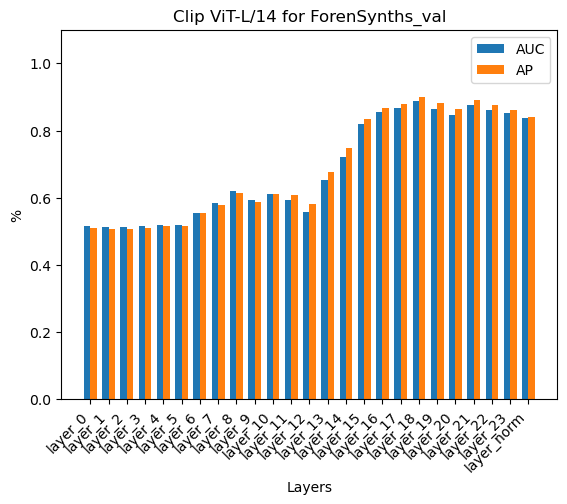

In [196]:
scores_layers(clip_l14_ForenSynths_val_df, "Clip ViT-L/14")

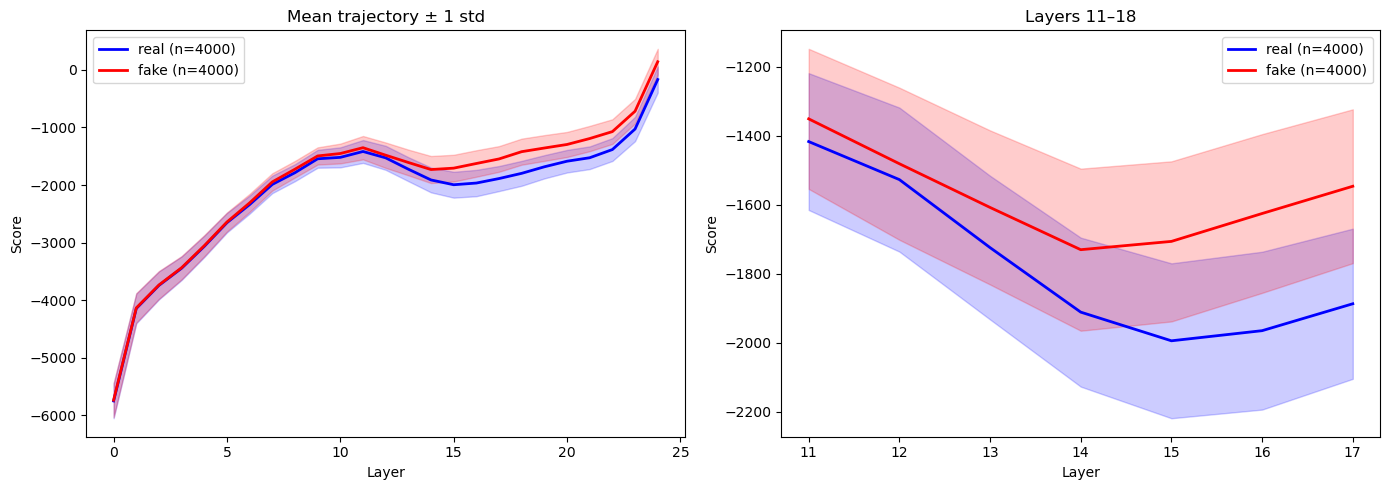

In [197]:
trajectory_plot(clip_l14_ForenSynths_val_df, (11, 18), 24)

In [198]:
delta_mining(clip_l14_ForenSynths_val_df)

,delta,auc,ap
132,layer_16-12,0.990990,0.985652
148,layer_17-12,0.990180,0.986943
165,layer_18-12,0.990004,0.987341
133,layer_16-13,0.988549,0.981546
117,layer_15-12,0.987729,0.985034
...,...,...,...
207,layer_20-17,0.312047,0.376966
249,layer_22-18,0.311798,0.377071
209,layer_20-19,0.253486,0.359200
189,layer_19-18,0.172365,0.335439


In [199]:
clip_l14_Imagenet5k_cal_df["layer_16-12"] = clip_l14_Imagenet5k_cal_df["layer_16"] - clip_l14_Imagenet5k_cal_df["layer_12"]
clip_l14_ForenSynths_test_df["layer_16-12"] = clip_l14_ForenSynths_test_df["layer_16"] - clip_l14_ForenSynths_test_df["layer_12"]
clip_l14_NewGenerator_test_df["layer_16-12"] = clip_l14_NewGenerator_test_df["layer_16"] - clip_l14_NewGenerator_test_df["layer_12"]

In [200]:
analyze_layer(clip_l14_ForenSynths_test_df, clip_l14_Imagenet5k_cal_df, generators, "layer_norm")

Mean+std cal set threshold: 95.3535

stylegan      ACC:0.6971  AP:0.8217  AUC:0.8294  F1:0.6150
stargan       ACC:0.5283  AP:0.9580  AUC:0.9636  F1:0.1087
stylegan2     ACC:0.6878  AP:0.8217  AUC:0.8228  F1:0.5900
biggan        ACC:0.6720  AP:0.7478  AUC:0.7314  F1:0.6024
progan        ACC:0.7303  AP:0.8505  AUC:0.8414  F1:0.7147


ValueError: Found array with 0 sample(s) (shape=(0,)) while a minimum of 1 is required.

In [ ]:
analyze_layer(clip_l14_ForenSynths_test_df, clip_l14_Imagenet5k_cal_df, generators, "layer_16-12")

Mean+std cal set threshold: -339.7311

stylegan      AUC:0.8180  AP:0.8140  ACC:0.7397  F1:0.7067
stargan       AUC:0.9852  AP:0.9795  ACC:0.9337  F1:0.9372
stylegan2     AUC:0.7825  AP:0.7685  ACC:0.6679  F1:0.5649
biggan        AUC:0.9301  AP:0.8973  ACC:0.8648  F1:0.8680
progan        AUC:0.9885  AP:0.9852  ACC:0.9248  F1:0.9358


ValueError: Found array with 0 sample(s) (shape=(0,)) while a minimum of 1 is required.

Mean+std cal set threshold: 95.3535

dalle3                AUC:0.4112  AP:0.1349  ACC:0.7180  F1:0.0942
firefly               AUC:0.4755  AP:0.1609  ACC:0.7282  F1:0.1545
flux                  AUC:0.2721  AP:0.3639  ACC:0.4307  F1:0.0297
midjourney-v5         AUC:0.4934  AP:0.1556  ACC:0.7222  F1:0.1194
sd3                   AUC:0.4357  AP:0.4602  ACC:0.4851  F1:0.1968
sdxl                  AUC:0.6313  AP:0.6042  ACC:0.5720  F1:0.4121
Macro-average AUC: 0.4532
Macro-average AP:  0.3133
Macro-average ACC: 0.6094
Macro-average F1:  0.1678


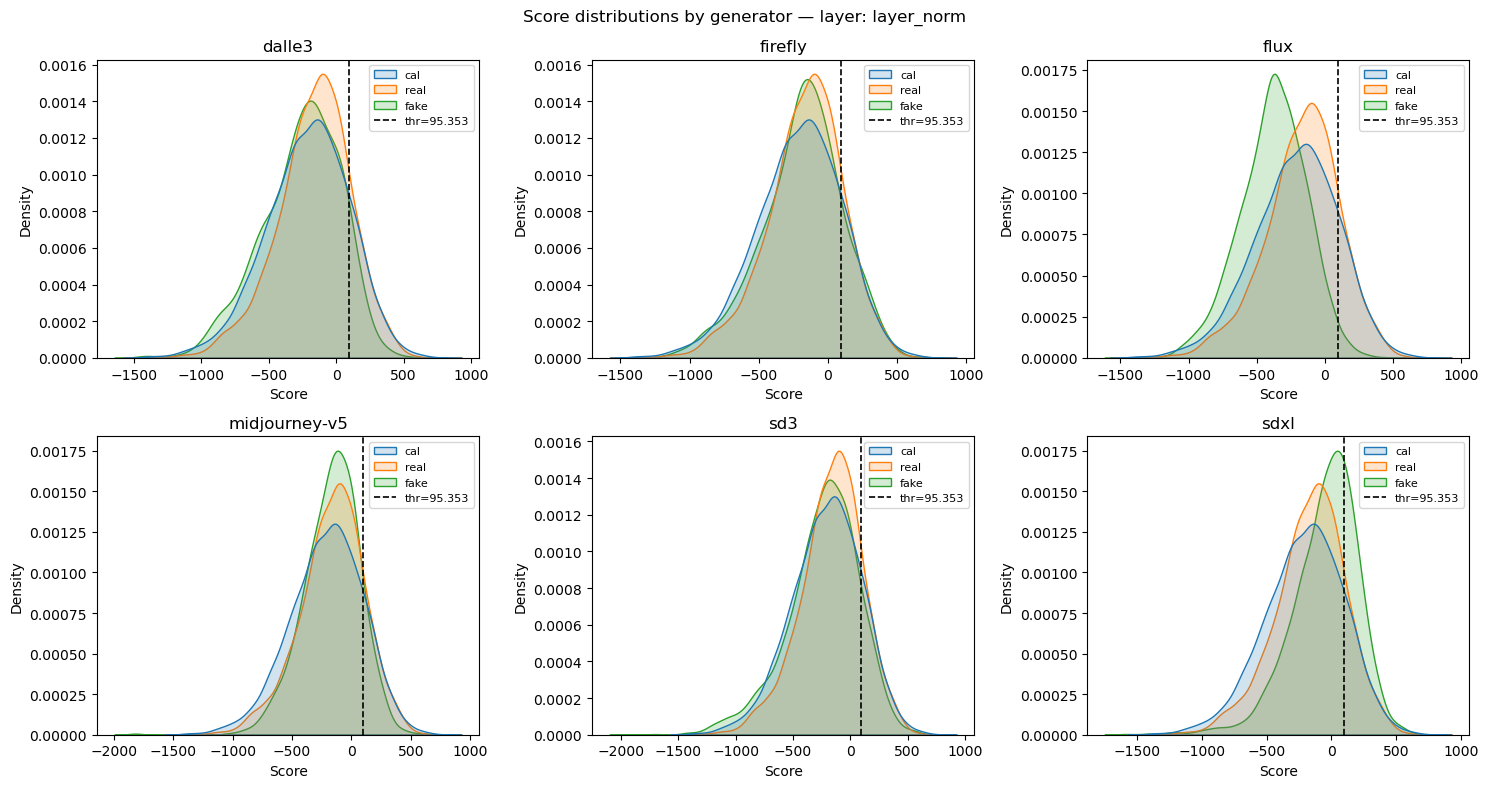

In [ ]:
specific_layer_score_new_gen(clip_l14_NewGenerator_test_df, "layer_norm", clip_l14_Imagenet5k_cal_df)

Mean+std cal set threshold: -339.7311

dalle3                AUC:0.9181  AP:0.6045  ACC:0.8793  F1:0.6295
firefly               AUC:0.8454  AP:0.4794  ACC:0.8447  F1:0.4662
flux                  AUC:0.7066  AP:0.6464  ACC:0.5407  F1:0.2452
midjourney-v5         AUC:0.8326  AP:0.4256  ACC:0.8352  F1:0.4144
sd3                   AUC:0.9234  AP:0.9063  ACC:0.8042  F1:0.7755
sdxl                  AUC:0.8300  AP:0.7928  ACC:0.6400  F1:0.4914
Macro-average AUC: 0.8427
Macro-average AP:  0.6425
Macro-average ACC: 0.7573
Macro-average F1:  0.5037


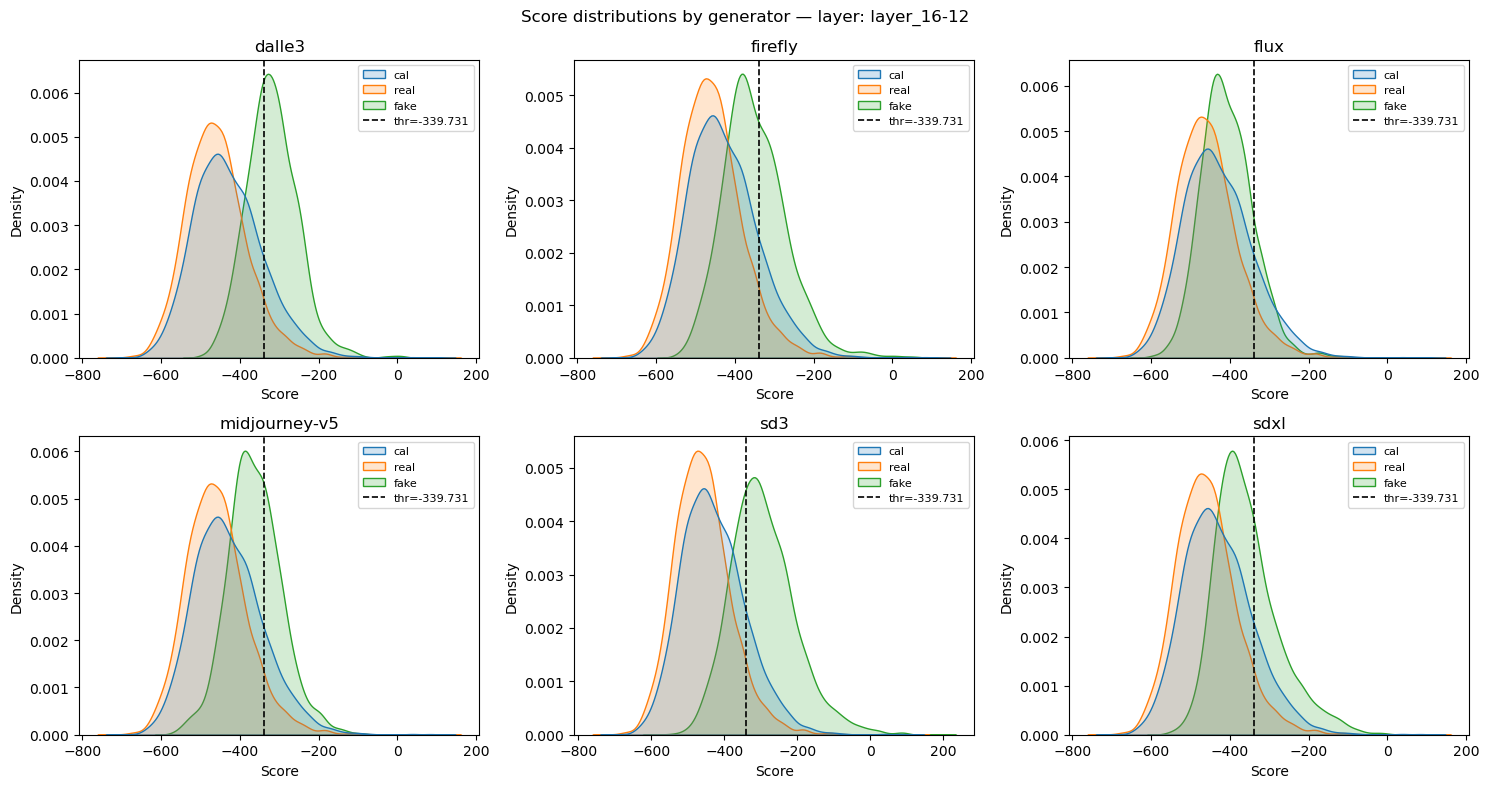

In [ ]:
specific_layer_score_new_gen(clip_l14_NewGenerator_test_df, "layer_16-12", clip_l14_Imagenet5k_cal_df)

## DINOv3-L/16

In [201]:
dinov3_l16_ForenSynths_val_df = read_jsonl("/home/tischuet/zero-shot-deepfake-detection/outputs/vit_large_patch16_dinov3_lvd1689m/vit_large_patch16_dinov3_lvd1689m_layerwise_ForenSynths_val.jsonl")
dinov3_l16_Imagenet5k_cal_df = read_jsonl("/home/tischuet/zero-shot-deepfake-detection/outputs/vit_large_patch16_dinov3_lvd1689m/vit_large_patch16_dinov3_lvd1689m_layerwise_Imagenet_val_5k.jsonl")

dinov3_l16_ForenSynths_test_df = read_jsonl("/home/tischuet/zero-shot-deepfake-detection/outputs/vit_large_patch16_dinov3_lvd1689m/vit_large_patch16_dinov3_lvd1689m_layerwise_ForenSynths.jsonl")
dinov3_l16_NewGenerator_test_df = read_jsonl("/home/tischuet/zero-shot-deepfake-detection/outputs/vit_large_patch16_dinov3_lvd1689m/vit_large_patch16_dinov3_lvd1689m_layerwise_New-Generator.jsonl")

AUC: [0.5200289687499999, 0.5195412187499999, 0.5302259687499999, 0.53767240625, 0.5397591875000001, 0.5387608749999999, 0.5599168437500001, 0.55329784375, 0.549347, 0.5681739062500001, 0.59175303125, 0.6100611249999999, 0.65155984375, 0.6978206250000001, 0.7207946875, 0.7545784375000001, 0.800229125, 0.8399001875000001, 0.8794315312500001, 0.9084471875, 0.912289125, 0.9080632187500002, 0.8950617499999999, 0.9111810312499999, 0.9267244062500002]
AP: [0.5210929013309946, 0.5191090123256792, 0.5221217974854833, 0.529890720129953, 0.529762390670147, 0.5304378617062956, 0.5510228979612499, 0.5590937494438063, 0.5652473376998759, 0.5932247777571042, 0.6284727544337555, 0.6401512926025043, 0.6787271835789035, 0.7234918927871439, 0.74409774699619, 0.776462639598702, 0.8172531026852993, 0.8552792062825659, 0.8904511299497628, 0.9164144112118586, 0.9199960649878771, 0.9166111951205135, 0.9048393934545511, 0.9181449350136551, 0.9326188200236203]


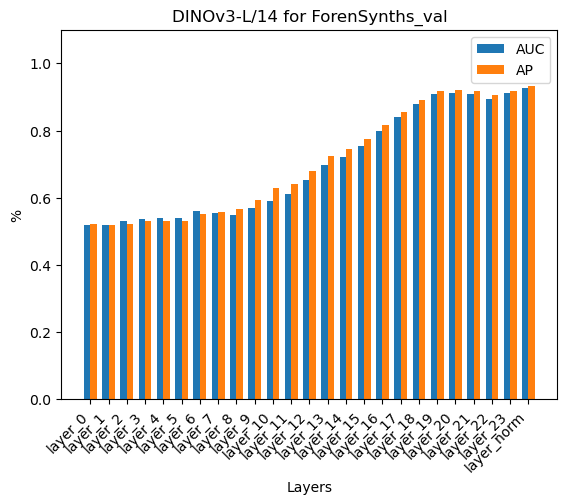

In [202]:
scores_layers(dinov3_l16_ForenSynths_val_df, "DINOv3-L/14")

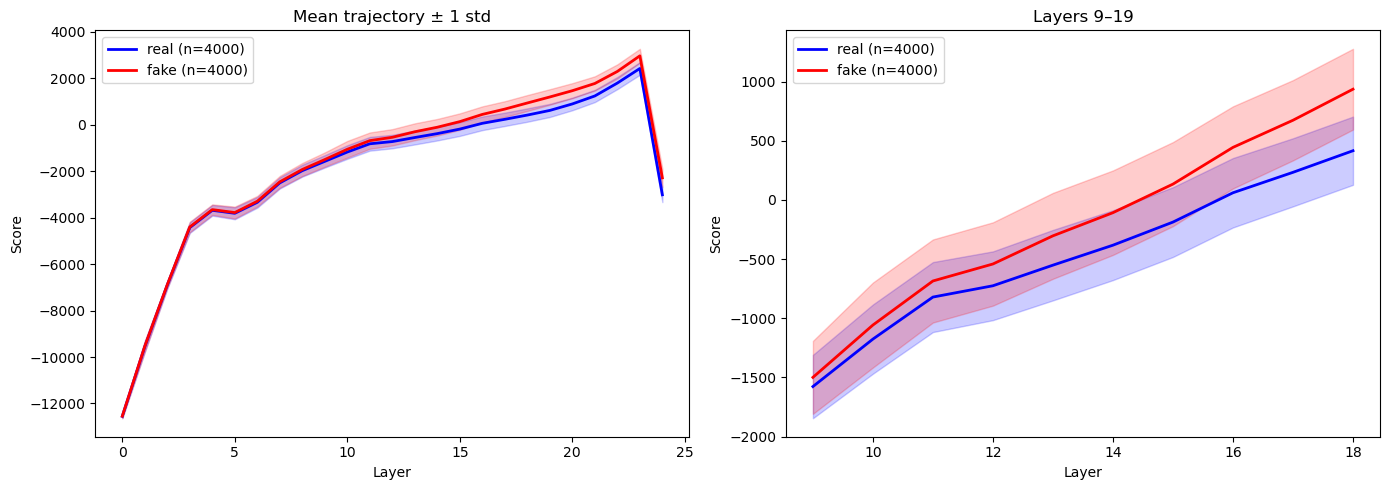

In [203]:
trajectory_plot(dinov3_l16_ForenSynths_val_df, (9, 19), 24)

In [204]:
delta_mining(dinov3_l16_ForenSynths_val_df).head(10)

,delta,auc,ap
179,layer_19-8,0.983902,0.985379
161,layer_18-8,0.983060,0.984187
162,layer_18-9,0.981062,0.982859
145,layer_17-9,0.980345,0.981032
131,layer_16-11,0.979990,0.981545
180,layer_19-9,0.979588,0.982021
144,layer_17-8,0.979435,0.979644
147,layer_17-11,0.977449,0.980460
129,layer_16-9,0.977332,0.976373
178,layer_19-7,0.976889,0.978364


In [205]:
dinov3_l16_Imagenet5k_cal_df["layer_19-8"] = dinov3_l16_Imagenet5k_cal_df["layer_19"] - dinov3_l16_Imagenet5k_cal_df["layer_8"]
dinov3_l16_ForenSynths_test_df["layer_19-8"] = dinov3_l16_ForenSynths_test_df["layer_19"] - dinov3_l16_ForenSynths_test_df["layer_8"]
dinov3_l16_NewGenerator_test_df["layer_19-8"] = dinov3_l16_NewGenerator_test_df["layer_19"] - dinov3_l16_NewGenerator_test_df["layer_8"]

Mean+std cal set threshold: -2778.6888

stylegan      ACC:0.6973  AP:0.7966  AUC:0.8059  F1:0.6472
stargan       ACC:0.8104  AP:0.8966  AUC:0.9003  F1:0.8179
stylegan2     ACC:0.7074  AP:0.8150  AUC:0.8197  F1:0.6567
biggan        ACC:0.7123  AP:0.7983  AUC:0.7846  F1:0.6978
progan        ACC:0.8384  AP:0.9313  AUC:0.9273  F1:0.8470
gaugan        ACC:0.8229  AP:0.9096  AUC:0.9070  F1:0.8314
cyclegan      ACC:0.6949  AP:0.8137  AUC:0.8237  F1:0.6129

Macro-average AUC: 0.8526
Macro-average AP:  0.8516
Macro-average ACC: 0.7548
Macro-average F1:  0.7301


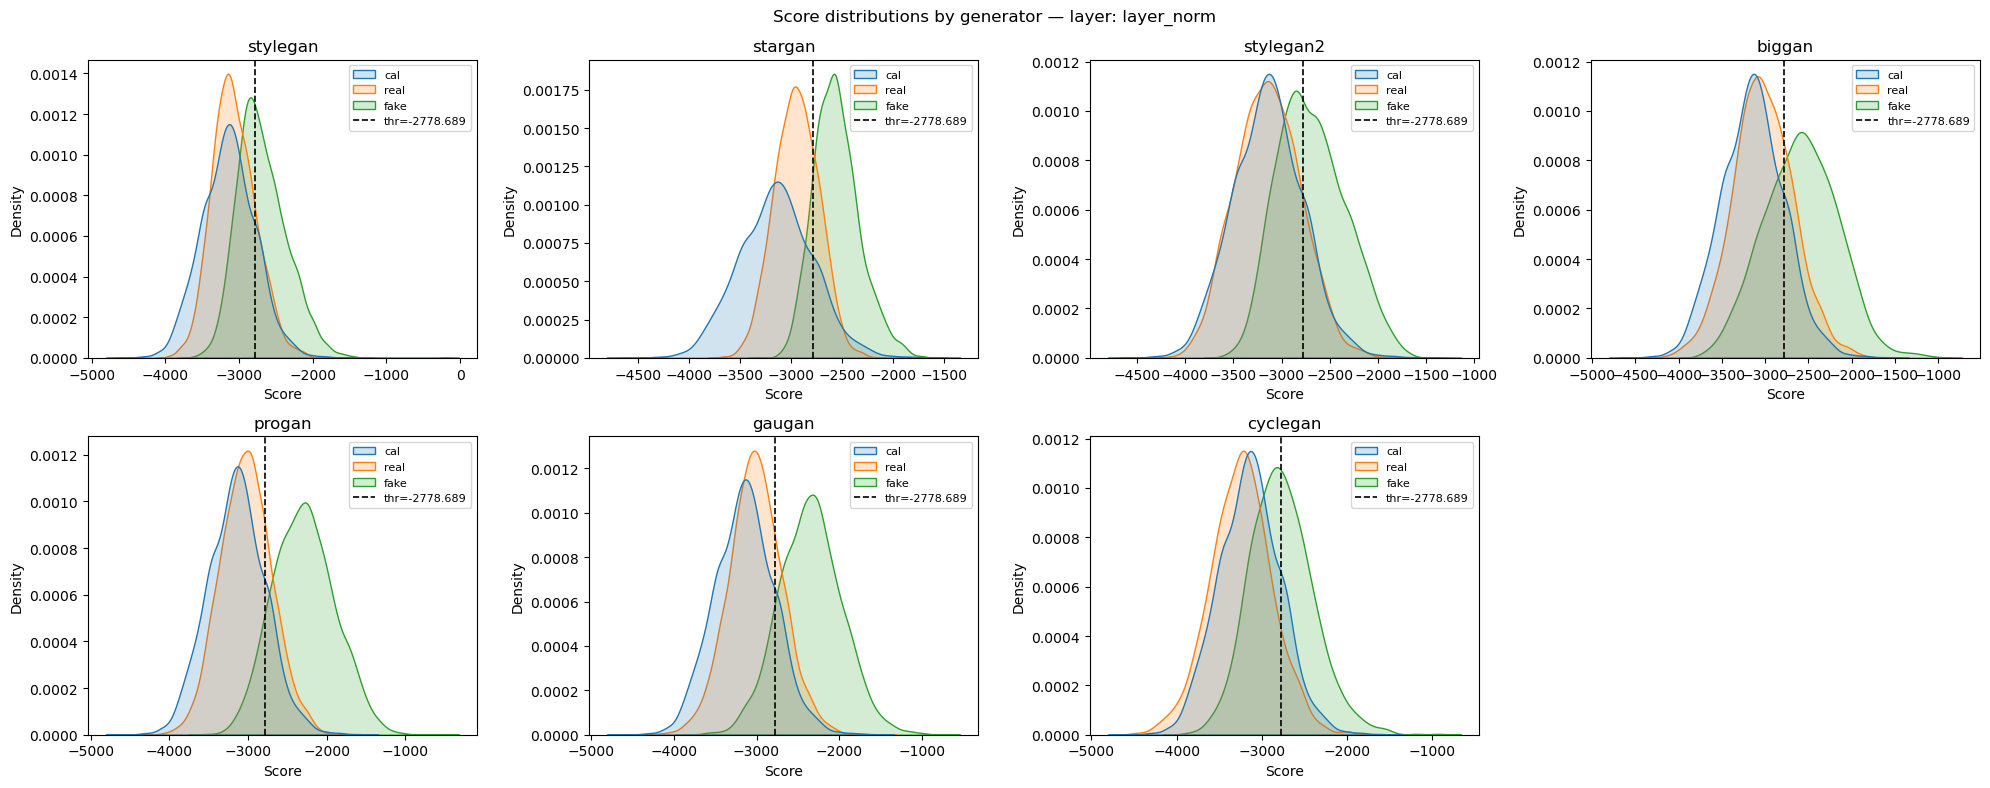

In [206]:
analyze_layer(dinov3_l16_ForenSynths_test_df, dinov3_l16_Imagenet5k_cal_df, generators, "layer_norm")

Mean+std cal set threshold: 2821.9142

stylegan      ACC:0.7066  AP:0.8486  AUC:0.8233  F1:0.6030
stargan       ACC:0.9430  AP:0.9834  AUC:0.9854  F1:0.9429
stylegan2     ACC:0.7153  AP:0.8418  AUC:0.8094  F1:0.6248
biggan        ACC:0.8728  AP:0.9445  AUC:0.9458  F1:0.8775
progan        ACC:0.9435  AP:0.9878  AUC:0.9863  F1:0.9443
gaugan        ACC:0.9044  AP:0.9804  AUC:0.9817  F1:0.9113
cyclegan      ACC:0.8709  AP:0.9323  AUC:0.9445  F1:0.8665

Macro-average AUC: 0.9252
Macro-average AP:  0.9312
Macro-average ACC: 0.8509
Macro-average F1:  0.8243


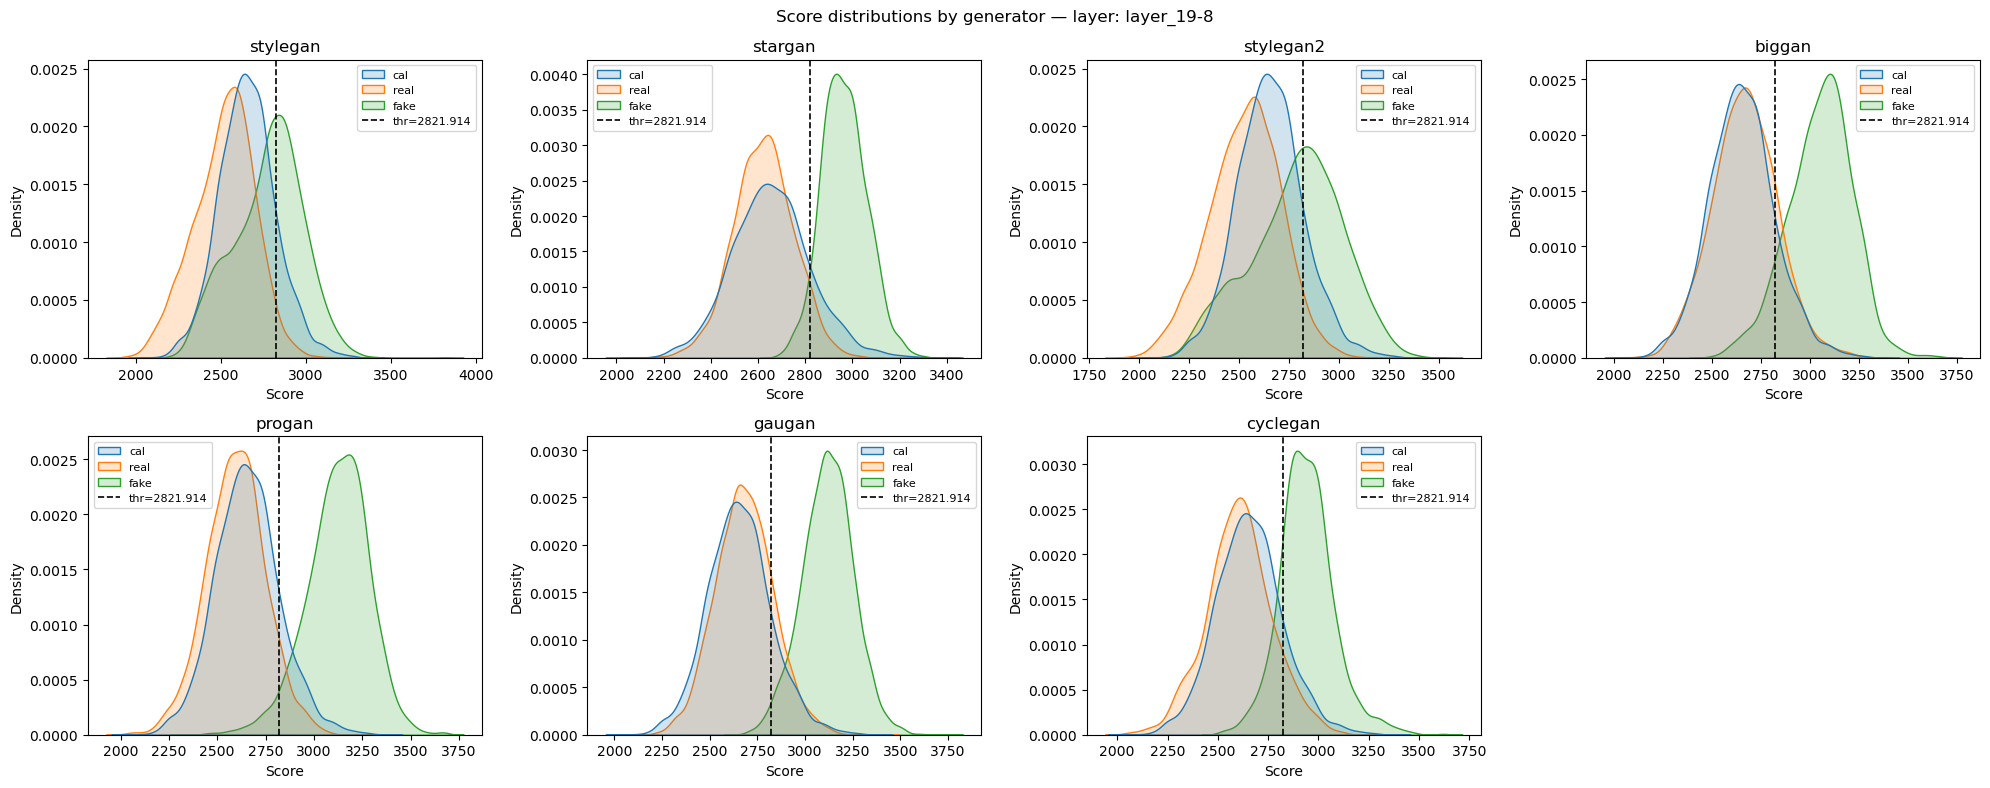

In [207]:
analyze_layer(dinov3_l16_ForenSynths_test_df, dinov3_l16_Imagenet5k_cal_df, generators, "layer_19-8")

Mean+std cal set threshold: -2778.6888

sd3                   ACC:0.6709  AP:0.7369  AUC:0.7146  F1:0.6226
flux                  ACC:0.5172  AP:0.5375  AUC:0.5674  F1:0.3280
sdxl                  ACC:0.7095  AP:0.7535  AUC:0.7887  F1:0.6810
dalle3                ACC:0.6768  AP:0.1181  AUC:0.3377  F1:0.0646
firefly               ACC:0.7337  AP:0.3070  AUC:0.6651  F1:0.3380
midjourney-v5         ACC:0.7247  AP:0.2547  AUC:0.6460  F1:0.3000
Macro-average AUC: 0.6199
Macro-average AP:  0.4513
Macro-average ACC: 0.6721
Macro-average F1:  0.3890


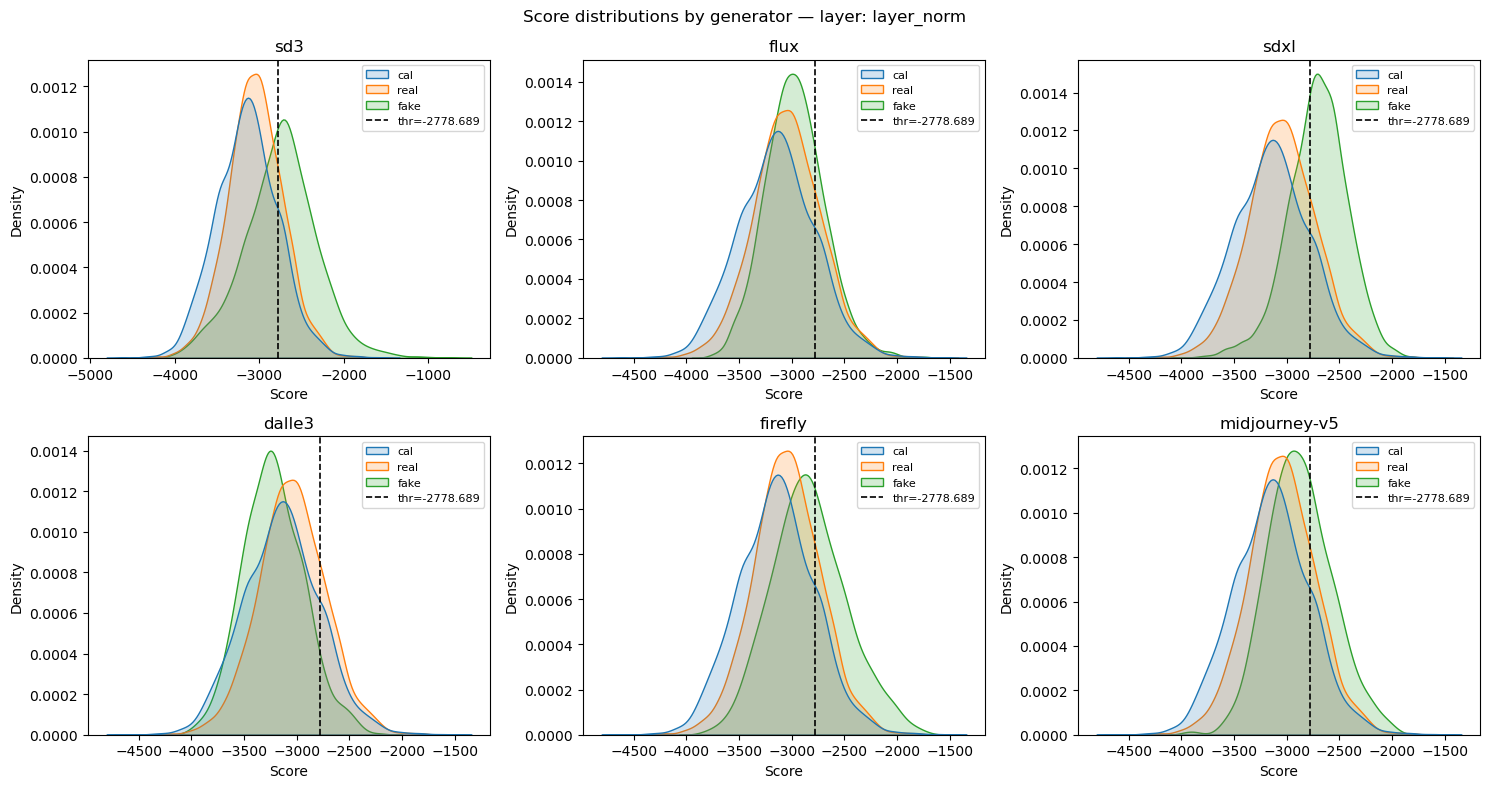

In [208]:
specific_layer_score_new_gen(dinov3_l16_NewGenerator_test_df, "layer_norm", dinov3_l16_Imagenet5k_cal_df)

Mean+std cal set threshold: 2821.9142

sd3                   ACC:0.6997  AP:0.7806  AUC:0.7702  F1:0.6500
flux                  ACC:0.4578  AP:0.3948  AUC:0.3123  F1:0.1201
sdxl                  ACC:0.5257  AP:0.5410  AUC:0.5440  F1:0.3067
dalle3                ACC:0.7097  AP:0.1179  AUC:0.3404  F1:0.0543
firefly               ACC:0.7447  AP:0.2217  AUC:0.5949  F1:0.2534
midjourney-v5         ACC:0.7332  AP:0.1795  AUC:0.5195  F1:0.1926
Macro-average AUC: 0.5135
Macro-average AP:  0.3726
Macro-average ACC: 0.6451
Macro-average F1:  0.2629


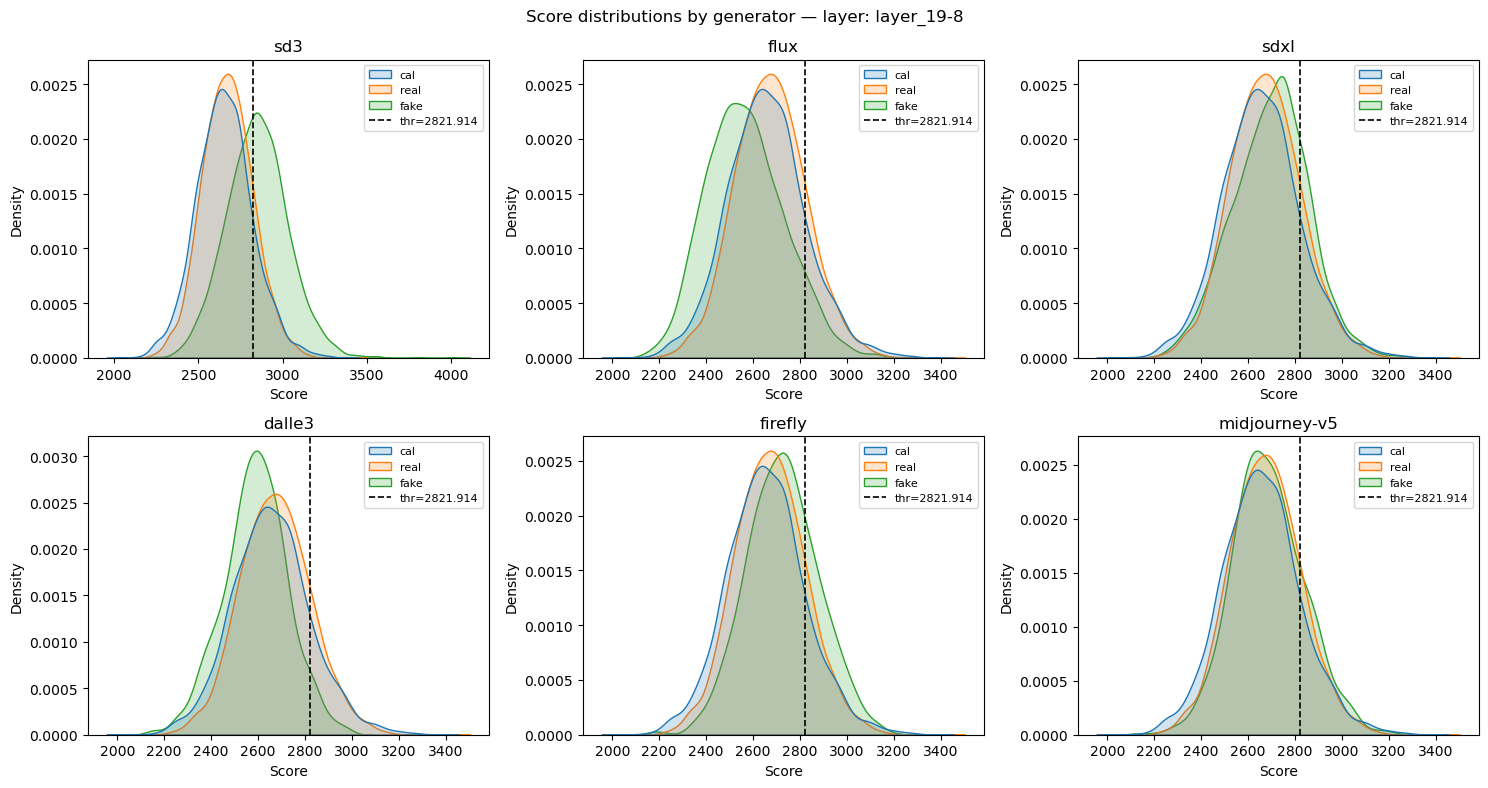

In [209]:
specific_layer_score_new_gen(dinov3_l16_NewGenerator_test_df, "layer_19-8", dinov3_l16_Imagenet5k_cal_df)

## Metaclip ViT-L/14

In [ ]:
metaclip_l14_ForenSynths_val_df = read_jsonl("/home/tischuet/zero-shot-deepfake-detection/outputs/vit_large_patch14_clip_quickgelu_224_metaclip_400m/vit_large_patch14_clip_quickgelu_224_metaclip_400m_layerwise_ForenSynths_val.jsonl")
metaclip_l14_Imagenet5k_cal_df = read_jsonl("/home/tischuet/zero-shot-deepfake-detection/outputs/vit_large_patch14_clip_quickgelu_224_metaclip_400m/vit_large_patch14_clip_quickgelu_224_metaclip_400m_layerwise_Imagenet_val_5k.jsonl")

metaclip_l14_ForenSynths_test_df = read_jsonl("/home/tischuet/zero-shot-deepfake-detection/outputs/vit_large_patch14_clip_quickgelu_224_metaclip_400m/vit_large_patch14_clip_quickgelu_224_metaclip_400m_layerwise_ForenSynths.jsonl")
metaclip_l14_NewGenerators_test_df = read_jsonl("/home/tischuet/zero-shot-deepfake-detection/outputs/vit_large_patch14_clip_quickgelu_224_metaclip_400m/vit_large_patch14_clip_quickgelu_224_metaclip_400m_layerwise_New-Generator.jsonl")

AUC: [0.512173, 0.5142495625, 0.51906453125, 0.53073671875, 0.537466125, 0.51722934375, 0.4966764375, 0.50130940625, 0.5250524375, 0.519537125, 0.56258059375, 0.6158080625, 0.67221396875, 0.7433900625, 0.7946094374999999, 0.842606875, 0.8559650624999999, 0.84827184375, 0.849210375, 0.8480740312499999, 0.846643625, 0.84533871875, 0.8596805624999999, 0.8577411562499999, 0.8599321875000001]
AP: [0.5071504496492066, 0.5080748728154614, 0.5115519392949335, 0.5210056008098027, 0.5298252512181111, 0.5110810843982241, 0.4962574324103567, 0.495044382058187, 0.5183242464703594, 0.5092648136337263, 0.5492847192191326, 0.6104092858107041, 0.6702109534708499, 0.7477683527541882, 0.8064572286361342, 0.8567894249194371, 0.8701086092234152, 0.8624115042359344, 0.8615295374929854, 0.8598686521294931, 0.8584370770825105, 0.8560892334710037, 0.8689521763034473, 0.864313997950096, 0.86430154230889]


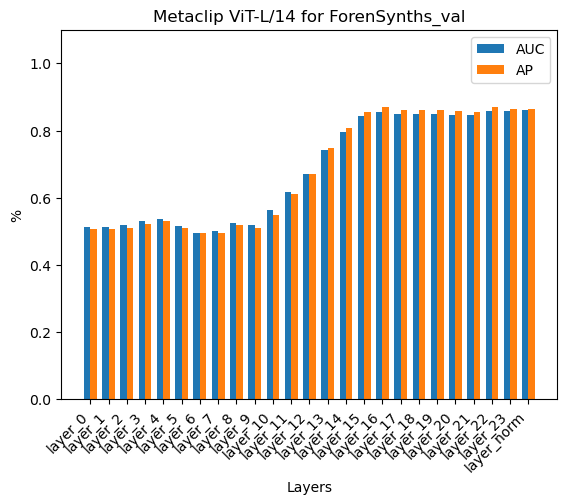

In [ ]:
scores_layers(metaclip_l14_ForenSynths_val_df, "Metaclip ViT-L/14")

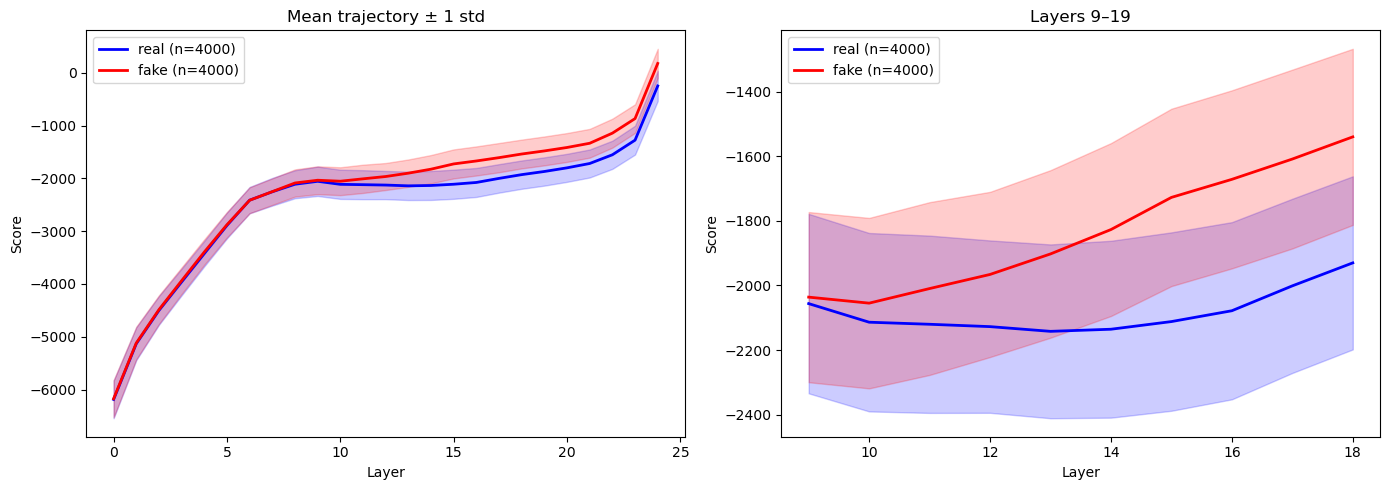

In [ ]:
trajectory_plot(metaclip_l14_ForenSynths_val_df, (9, 19), 24)

In [ ]:
delta_mining(metaclip_l14_ForenSynths_val_df)

,delta,auc,ap
115,layer_15-10,0.993150,0.993543
114,layer_15-9,0.991939,0.992389
130,layer_16-10,0.990853,0.990582
129,layer_16-9,0.990121,0.990094
116,layer_15-11,0.989616,0.990584
...,...,...,...
25,layer_7-4,0.404029,0.455181
14,layer_5-4,0.401698,0.451349
152,layer_17-16,0.391934,0.411680
20,layer_6-5,0.385598,0.446079


In [ ]:
metaclip_l14_Imagenet5k_cal_df["layer_15-10"] = metaclip_l14_Imagenet5k_cal_df["layer_15"] - metaclip_l14_Imagenet5k_cal_df["layer_10"]
metaclip_l14_ForenSynths_test_df["layer_15-10"] = metaclip_l14_ForenSynths_test_df["layer_15"] - metaclip_l14_ForenSynths_test_df["layer_10"]
metaclip_l14_NewGenerators_test_df["layer_15-10"] = metaclip_l14_NewGenerators_test_df["layer_15"] - metaclip_l14_NewGenerators_test_df["layer_10"]

In [ ]:
analyze_layer(metaclip_l14_ForenSynths_test_df, metaclip_l14_Imagenet5k_cal_df, generators, "layer_norm")

Mean+std cal set threshold: 76.4289

stylegan      AUC:0.8275  AP:0.8264  ACC:0.7062  F1:0.6298
stargan       AUC:0.9710  AP:0.9704  ACC:0.6718  F1:0.5130
stylegan2     AUC:0.7981  AP:0.8850  ACC:0.5619  F1:0.5154


ValueError: Found array with 0 sample(s) (shape=(0,)) while a minimum of 1 is required.

In [ ]:
analyze_layer(metaclip_l14_ForenSynths_test_df, metaclip_l14_Imagenet5k_cal_df, generators, "layer_15-10")

Mean+std cal set threshold: 103.1182

stylegan      AUC:0.8362  AP:0.8138  ACC:0.7414  F1:0.7341
stargan       AUC:0.6554  AP:0.5754  ACC:0.6358  F1:0.7129
stylegan2     AUC:0.7636  AP:0.8606  ACC:0.5859  F1:0.5656


ValueError: Found array with 0 sample(s) (shape=(0,)) while a minimum of 1 is required.

In [ ]:
specific_layer_score_new_gen(metaclip_l14_NewGenerators_test_df, "layer_norm", metaclip_l14_Imagenet5k_cal_df)

Mean+std cal set threshold: 76.4289

sd3                   AUC:nan  AP:1.0000  ACC:0.1386  F1:0.2435
flux                  AUC:nan  AP:1.0000  ACC:0.0656  F1:0.1231
sdxl                  AUC:nan  AP:1.0000  ACC:0.3718  F1:0.5421


/work/tischuet/miniconda3/envs/jepa/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/work/tischuet/miniconda3/envs/jepa/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/work/tischuet/miniconda3/envs/jepa/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


ValueError: Found array with 0 sample(s) (shape=(0,)) while a minimum of 1 is required.

In [ ]:
specific_layer_score_new_gen(metaclip_l14_NewGenerators_test_df, "layer_15-10", metaclip_l14_Imagenet5k_cal_df)

Mean+std cal set threshold: 103.1182

sd3                   AUC:nan  AP:1.0000  ACC:0.5572  F1:0.7156
flux                  AUC:nan  AP:1.0000  ACC:0.1818  F1:0.3077
sdxl                  AUC:nan  AP:1.0000  ACC:0.6448  F1:0.7841


/work/tischuet/miniconda3/envs/jepa/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/work/tischuet/miniconda3/envs/jepa/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/work/tischuet/miniconda3/envs/jepa/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


ValueError: Found array with 0 sample(s) (shape=(0,)) while a minimum of 1 is required.